<a href="https://www.kaggle.com/code/orxansmaylov92/job-salary-prediction-dataset-last?scriptVersionId=307002437" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [6]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             mean_absolute_error, r2_score, mean_squared_error,
                             precision_score, recall_score, f1_score, roc_curve, roc_auc_score)
import warnings
warnings.filterwarnings('ignore')
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/rhythmghai/250k-job-salary-prediction-dataset/job_salary_prediction_dataset.csv


In [7]:
df = pd.read_csv("/kaggle/input/datasets/rhythmghai/250k-job-salary-prediction-dataset/job_salary_prediction_dataset.csv")

In [8]:
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [9]:
df.isna().sum()

job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

******Exploratory Data Analysis (EDA)******

In [10]:
# Datasetin ölçüsü
print("Datasetin ölçüsü:")
print(f"Sətir sayı: {df.shape[0]}")
print(f"Sütun sayı: {df.shape[1]}")

# Sütun adları və məlumat tipləri
print("\n" + "=" * 50)
print("Sütun məlumatları:")
print(df.info())

# Statistik məlumatlar
print("\n" + "=" * 70)
print("Statistik məlumatlar:")
print(df.describe().round(2))

# Kateqorik dəyişənlər
print("\n" + "=" * 35)
print("Kateqorik dəyişənlər:")

kategorik_sutunlar = df.select_dtypes(include=['object']).columns
for col in kategorik_sutunlar:
    print(f"\n{col} - Unikal dəyərlər:")
    print(df[col].value_counts().head(10))  

# Numerik dəyişənlər
print("\n" + "=" * 80)
print("Numerik dəyişənlər:")

eded_sutunlar = df.select_dtypes(include=[np.number]).columns
print(f"Ədədi sütunlar: {list(eded_sutunlar)}")

# Çatışmayan dəyərlər (Missing Values)
print("\n" + "=" * 35)
print("Çatışmayan dəyərlər (Missing Values):")
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({
    'Çatışmayan say': missing_data,
    'Faiz (%)': missing_percent
})
print(missing_df[missing_df['Çatışmayan say'] > 0])

Datasetin ölçüsü:
Sətir sayı: 250000
Sütun sayı: 10

Sütun məlumatları:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB
None

Statistik məlumatlar:
       experience_years  skills_count  certifications     salary
count         250000.00     250000.00       250000.00  250000.00
mean              10.01         10.00       

### Vizuallaşdırma

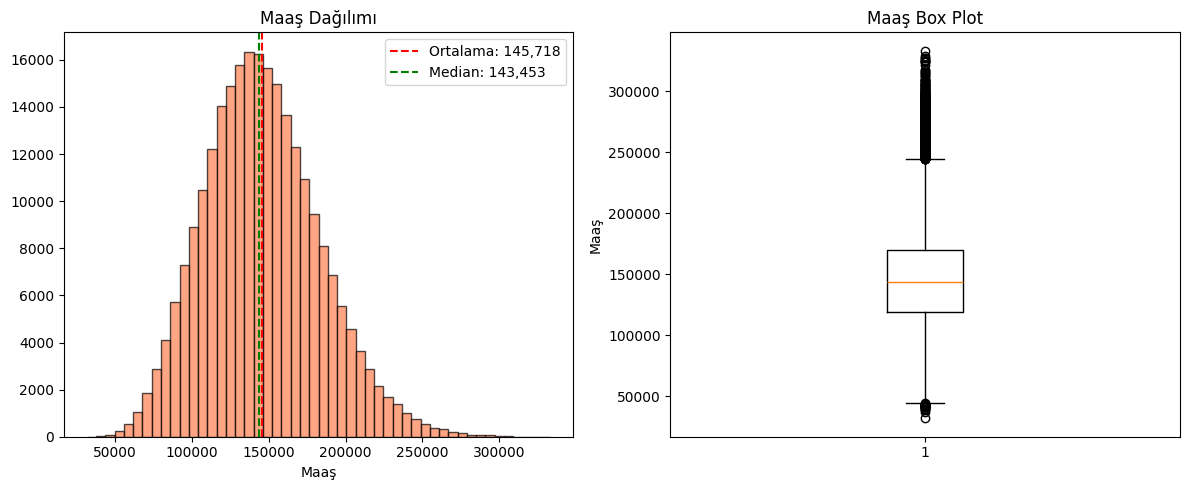


Maaş statistikası:
count    250000.00
mean     145718.08
std       37407.95
min       31867.00
25%      119358.00
50%      143453.00
75%      169492.00
max      333046.00
Name: salary, dtype: float64


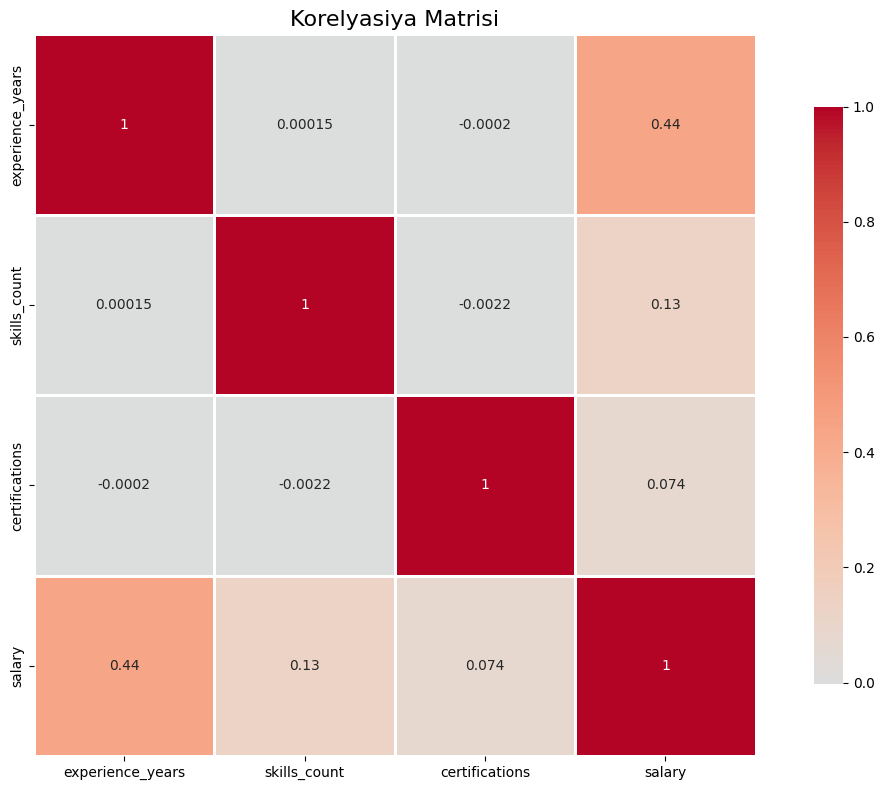


Yüksək korelyasiyalar (>0.5 və ya <-0.5):


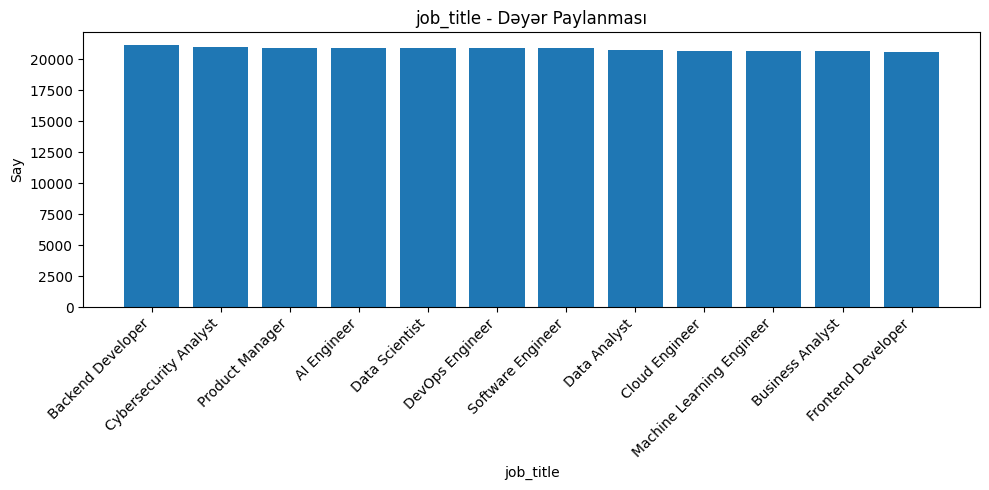

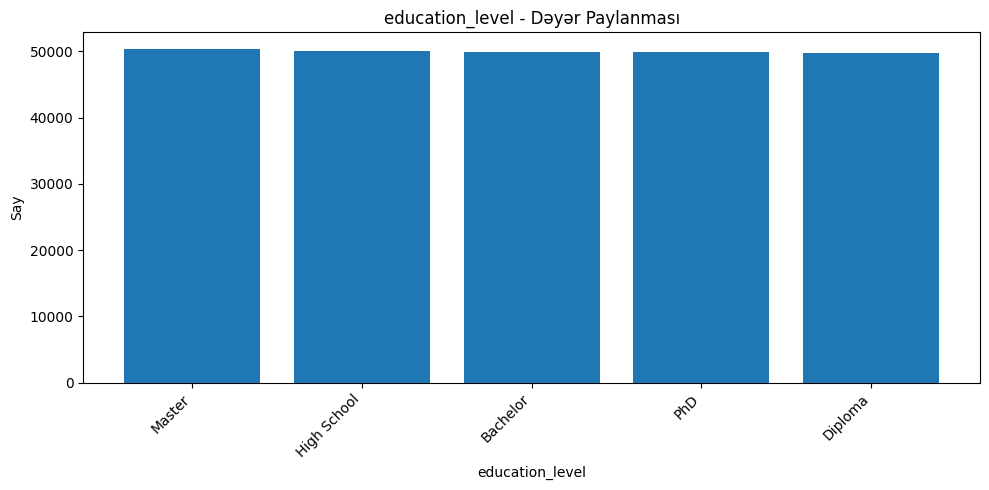

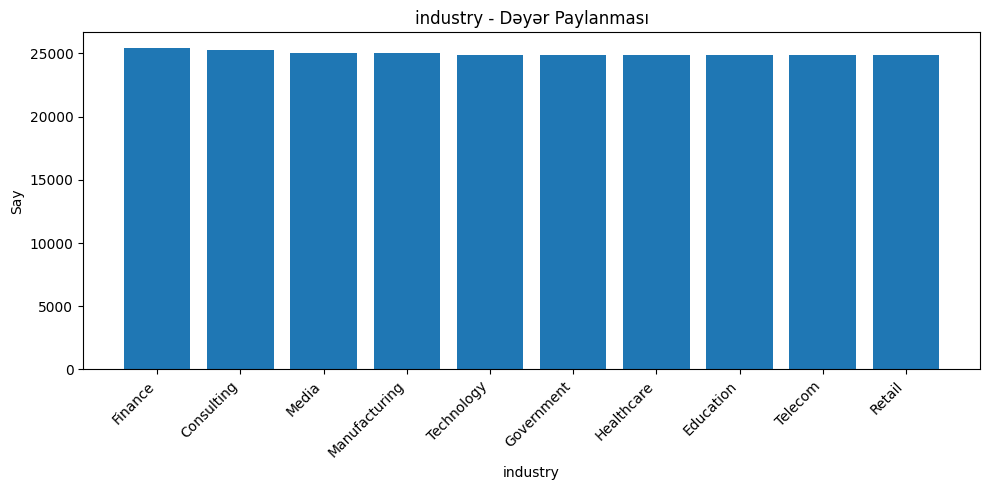

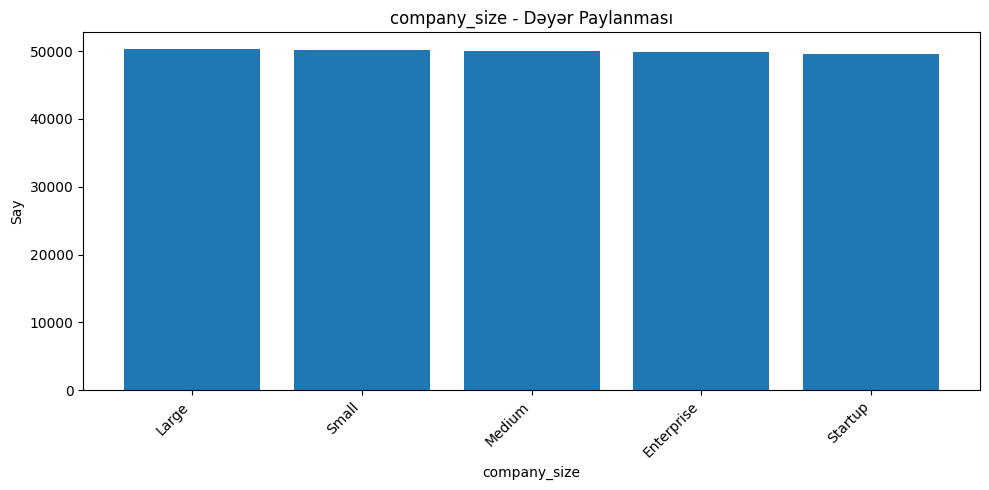

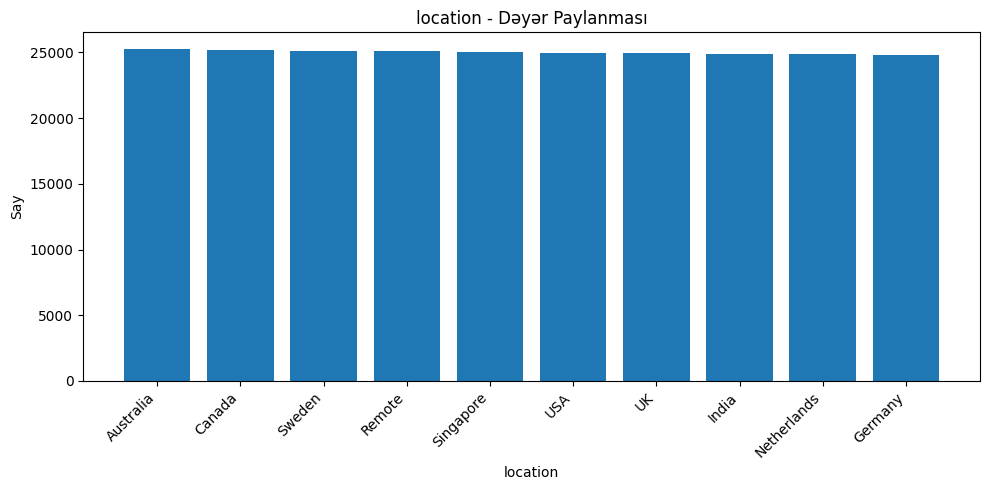

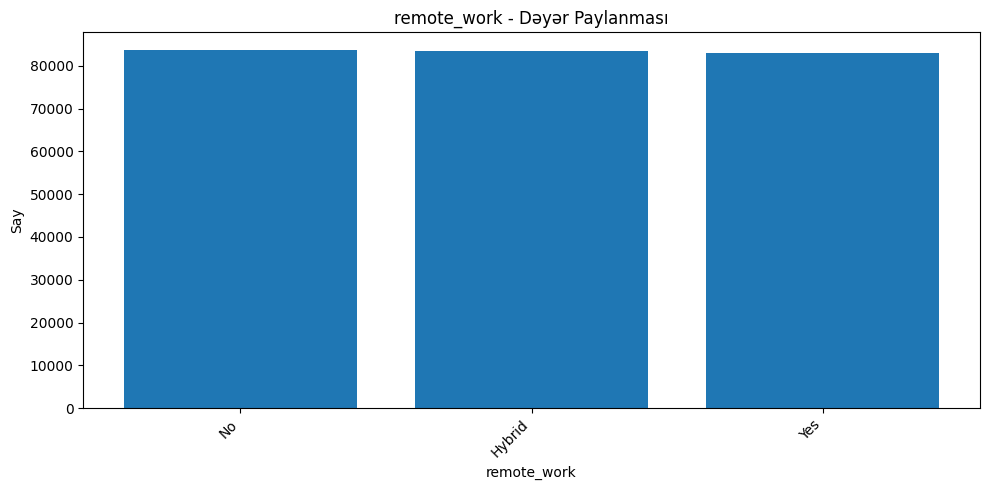

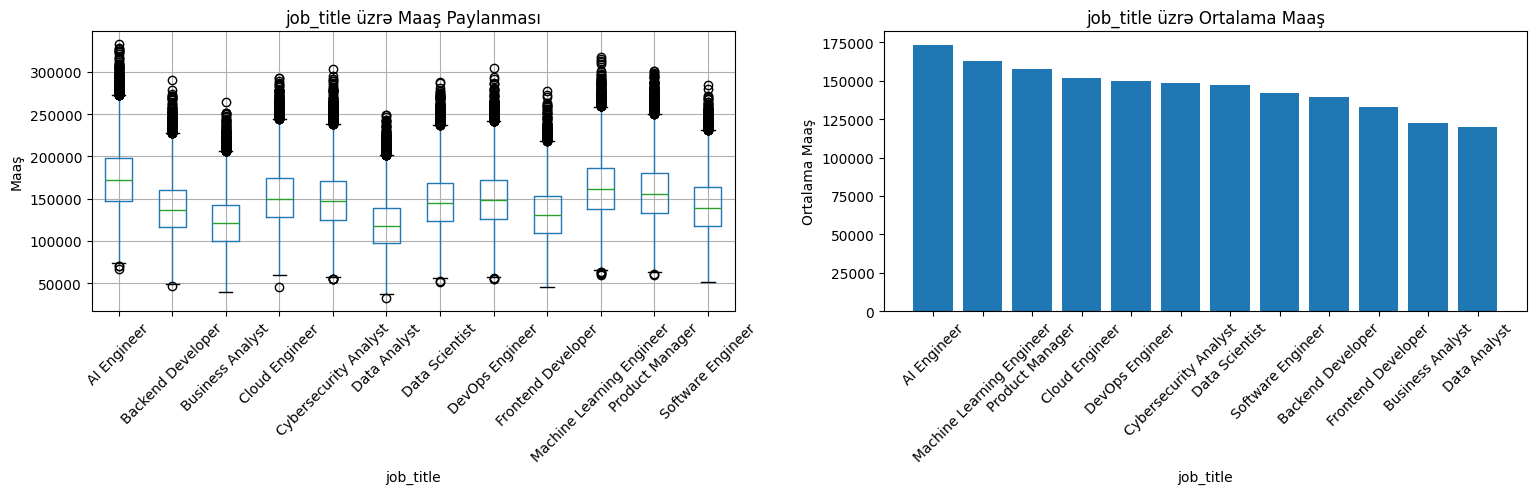

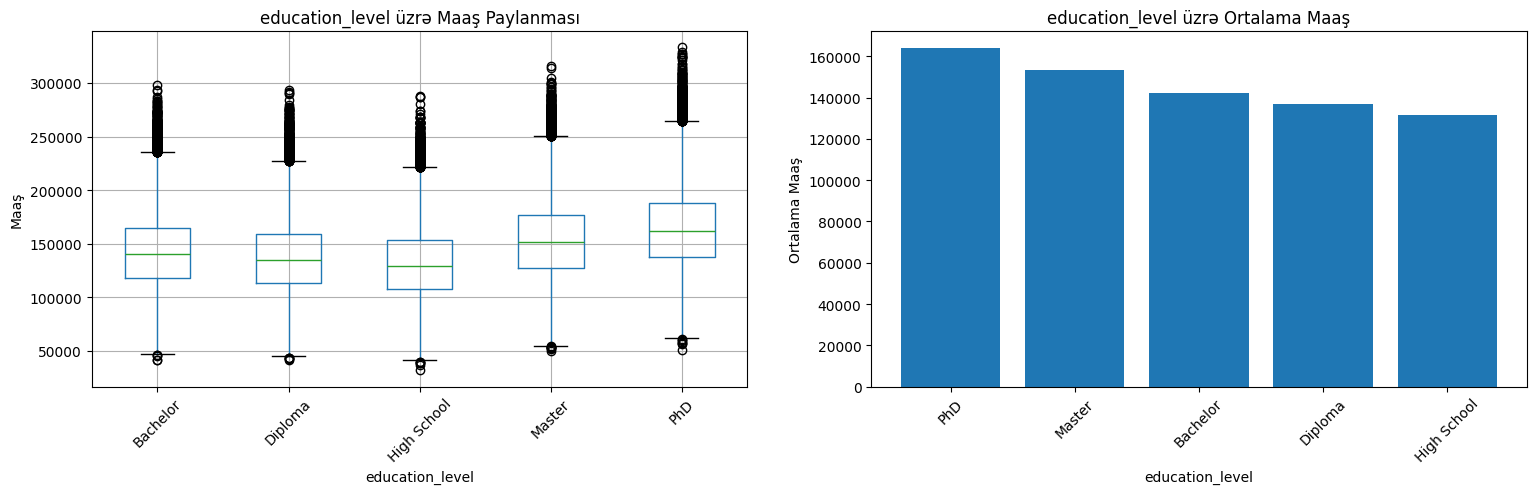

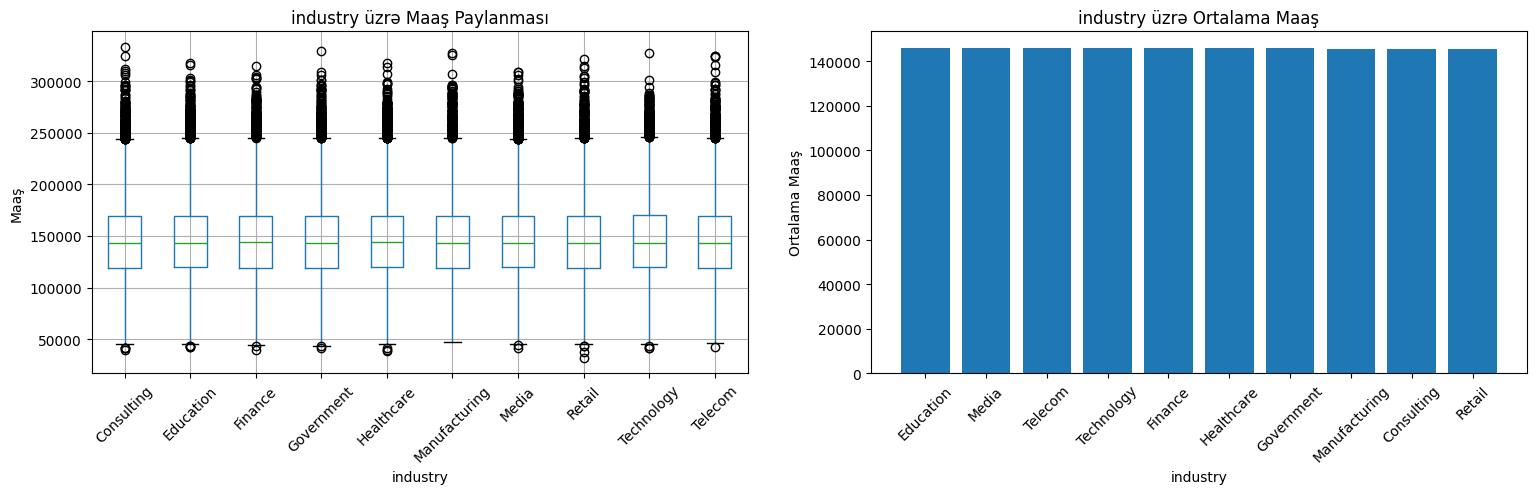

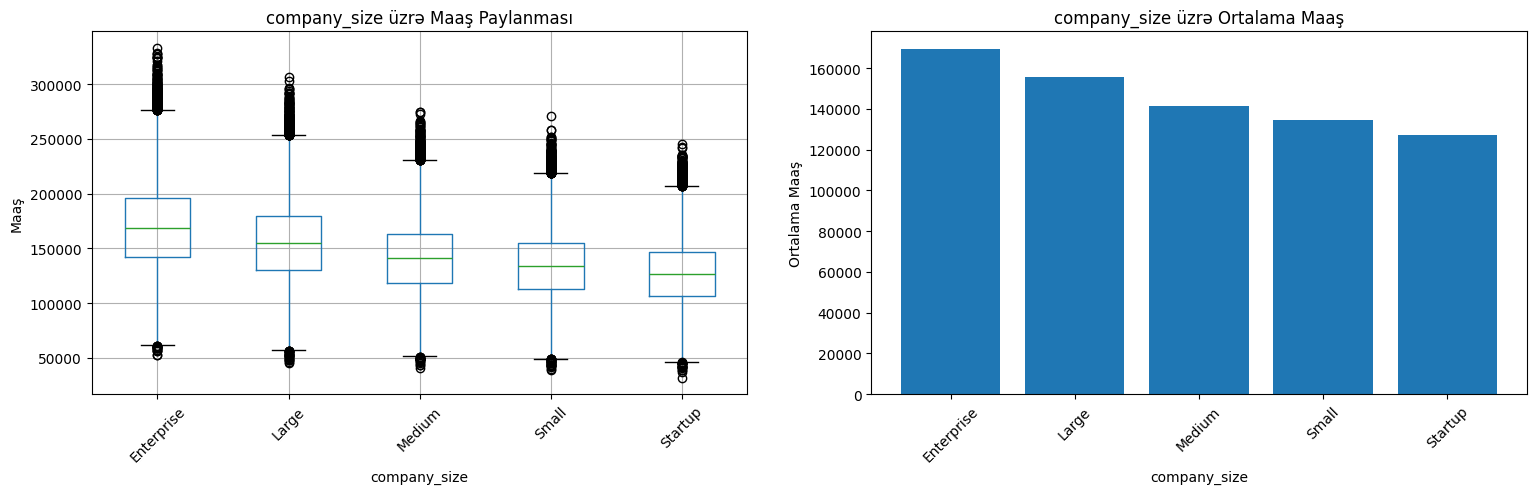

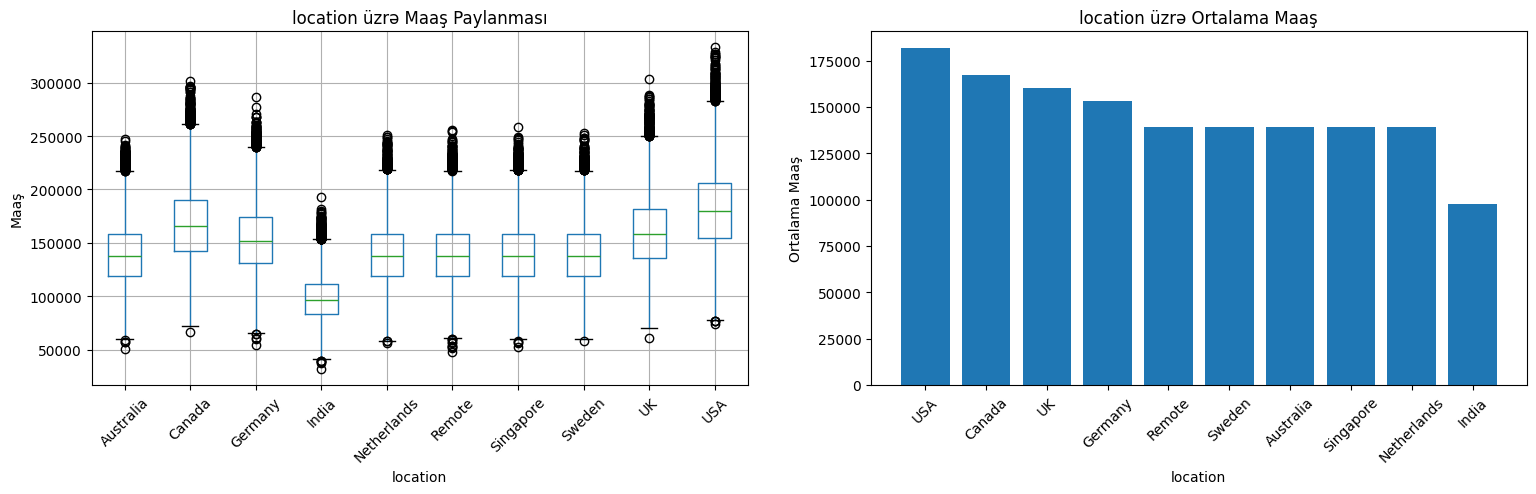

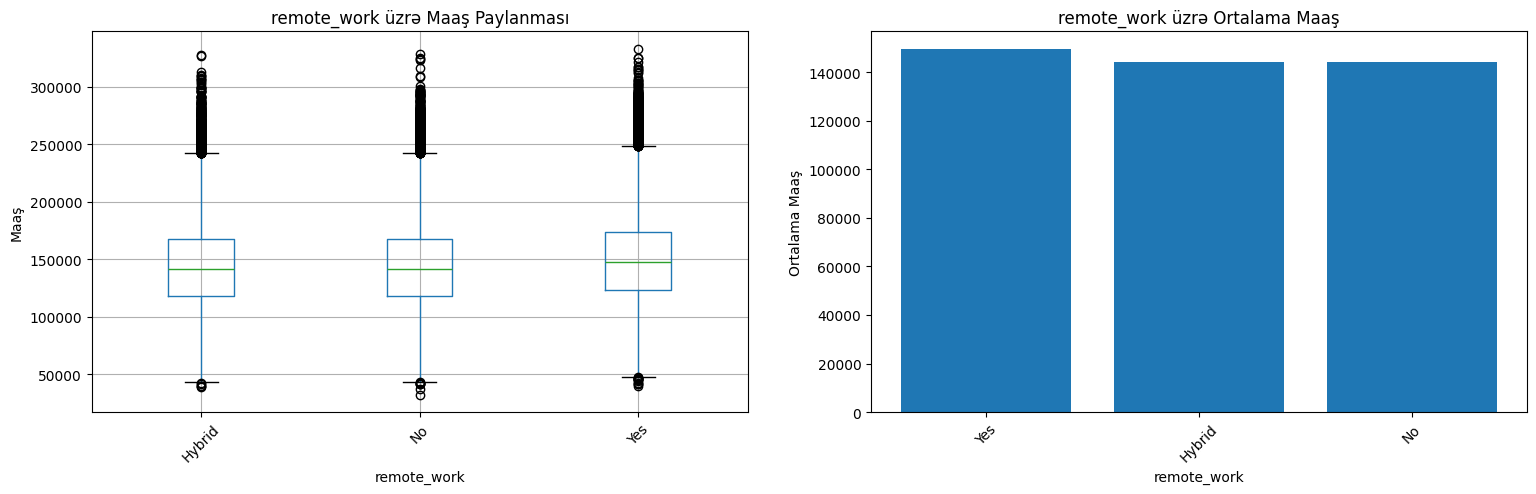


Outliers:
salary: 2336 Outliers (0.93%)
  Normal diapazon: [44157.00, 244693.00]
  Min: 31867.00, Max: 333046.00



In [11]:
# Maaş paylanması
salary_col = 'salary'

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

#  Histogram + ortalama + median
axes[0].hist(df[salary_col].dropna(), bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[0].axvline(df[salary_col].mean(), color='red', linestyle='--', label=f'Ortalama: {df[salary_col].mean():,.0f}')
axes[0].axvline(df[salary_col].median(), color='green', linestyle='--', label=f'Median: {df[salary_col].median():,.0f}')
axes[0].set_title('Maaş Dağılımı')
axes[0].set_xlabel('Maaş')
axes[0].legend()

# Box Plot
axes[1].boxplot(df[salary_col].dropna())
axes[1].set_title('Maaş Box Plot')
axes[1].set_ylabel('Maaş')


plt.tight_layout()
plt.show()

print(f"\nMaaş statistikası:")
print(df[salary_col].describe().round(2))

# Korelyasiya matrisi
if len(eded_sutunlar) > 1:
    plt.figure(figsize=(12, 8))
    correlation_matrix = df[eded_sutunlar].corr()
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
                square=True, linewidths=1, cbar_kws={"shrink": 0.8})
    plt.title('Korelyasiya Matrisi', fontsize=16)
    plt.tight_layout()
    plt.show()
    
    print("\nYüksək korelyasiyalar (>0.5 və ya <-0.5):")
    for i in range(len(correlation_matrix.columns)):
        for j in range(i+1, len(correlation_matrix.columns)):
            if abs(correlation_matrix.iloc[i, j]) > 0.5:
                print(f"{correlation_matrix.columns[i]} - {correlation_matrix.columns[j]}: {correlation_matrix.iloc[i, j]:.2f}")

# Kateqorik dəyişənlərin vizuallaşdırılması
if len(kategorik_sutunlar) > 0:
    for col in kategorik_sutunlar:
        plt.figure(figsize=(10, 5))
        
        value_counts = df[col].value_counts().head(15)
        
        plt.bar(range(len(value_counts)), value_counts.values)
        plt.xticks(range(len(value_counts)), value_counts.index, rotation=45, ha='right')
        plt.title(f'{col} - Dəyər Paylanması')
        plt.xlabel(col)
        plt.ylabel('Say')
        plt.tight_layout()
        plt.show()

# Maaş və kateqorik dəyişənlər arasında əlaqə
if len(kategorik_sutunlar) > 0:
    for col in kategorik_sutunlar:
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        # BOX PLOT
        df.boxplot(column=salary_col, by=col, ax=axes[0])
        axes[0].set_title(f'{col} üzrə Maaş Paylanması')
        axes[0].set_xlabel(col)
        axes[0].set_ylabel('Maaş')
        axes[0].tick_params(axis='x', rotation=45)
        
        # BAR PLOT (Average salary)
        avg_salary = df.groupby(col)[salary_col].mean().sort_values(ascending=False)
        
        axes[1].bar(avg_salary.index, avg_salary.values)
        axes[1].set_title(f'{col} üzrə Ortalama Maaş')
        axes[1].set_xlabel(col)
        axes[1].set_ylabel('Ortalama Maaş')
        axes[1].tick_params(axis='x', rotation=45)
        
        plt.suptitle('')
        plt.tight_layout(pad=3)
        plt.show()

# Outliers
print("\n" + "=" * 50)
print("Outliers:")
for col in eded_sutunlar:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_count = len(outliers)
    outlier_percent = (outlier_count / len(df)) * 100
    
    if outlier_count > 0:
        print(f"{col}: {outlier_count} Outliers ({outlier_percent:.2f}%)")
        print(f"  Normal diapazon: [{lower_bound:.2f}, {upper_bound:.2f}]")
        print(f"  Min: {df[col].min():.2f}, Max: {df[col].max():.2f}")
        print()

In [12]:
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [13]:
df['certifications'].unique()

array([2, 0, 1, 3, 5, 4])

In [14]:
# Vəzifələr üzrə statistik analiz

print("Peşələr üzrə statistik analiz")
print("=" * 60)

if salary_col in df.columns:
    print(f"\n📊 Maaş analizi")
    print(f"   • Sənayedə ortalama maaş: {df[salary_col].mean():,.0f}")
    print(f"   • Ən çox rastlanan maaş (median): {df[salary_col].median():,.0f}")
    print(f"   • Maaşlar arası fərq (range): {df[salary_col].max() - df[salary_col].min():,.0f}")
    
    # Maaş dilimləri
    print(f"\n📊 Maaş bölgüləri")
    percentiles = [10, 25, 50, 75, 90]
    for p in percentiles:
        val = df[salary_col].quantile(p/100)
        print(f"   • {p}%: {val:,.0f}")

# Ən yaxşı maaş verən işlər
if 'job_title' in df.columns:
    print(f"\n🏆 Peşələr üzrə maaşlar ardıcıl formada")
    top_paying = df.groupby('job_title')[salary_col].mean().nlargest(12)
    for job, salary in top_paying.items():
        print(f"   • {job}: {salary:,.0f}")

Peşələr üzrə statistik analiz

📊 Maaş analizi
   • Sənayedə ortalama maaş: 145,718
   • Ən çox rastlanan maaş (median): 143,453
   • Maaşlar arası fərq (range): 301,179

📊 Maaş bölgüləri
   • 10%: 99,024
   • 25%: 119,358
   • 50%: 143,453
   • 75%: 169,492
   • 90%: 194,946

🏆 Peşələr üzrə maaşlar ardıcıl formada
   • AI Engineer: 173,498
   • Machine Learning Engineer: 163,023
   • Product Manager: 157,595
   • Cloud Engineer: 152,103
   • DevOps Engineer: 149,959
   • Cybersecurity Analyst: 148,698
   • Data Scientist: 147,258
   • Software Engineer: 141,740
   • Backend Developer: 139,203
   • Frontend Developer: 132,654
   • Business Analyst: 122,551
   • Data Analyst: 119,892


Ümumi iş vəzifəsi sayı: 12

1. job_title ilə education_level analizi


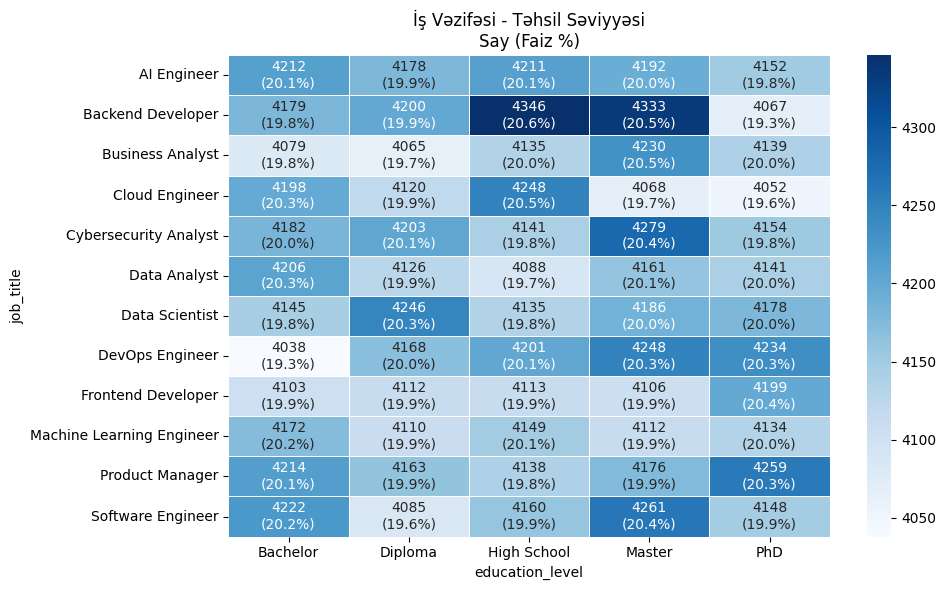


2. job_title ilə industry analizi


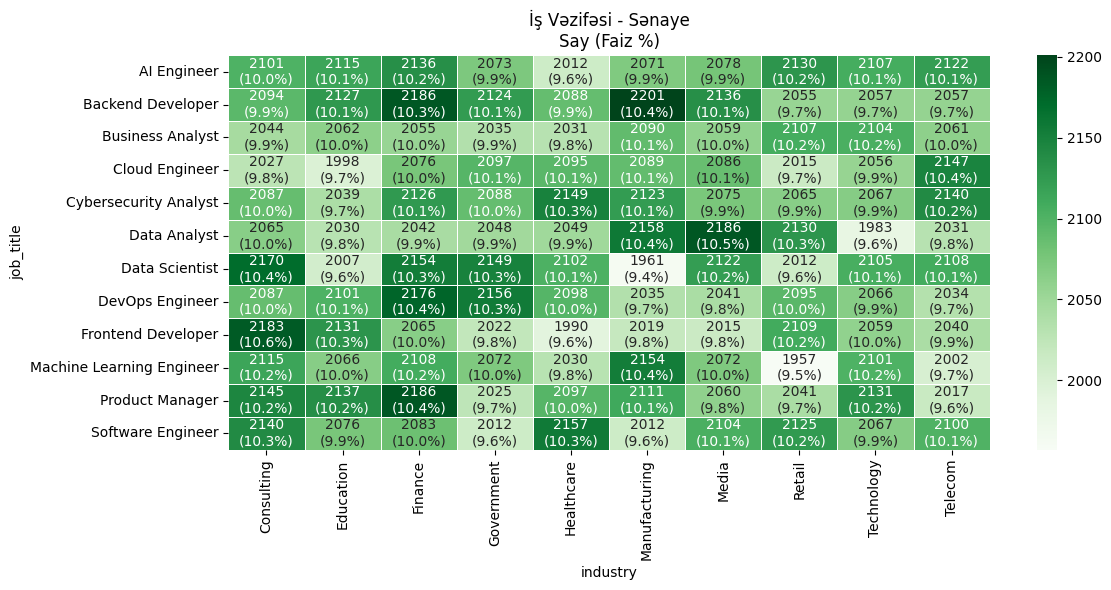


3. job_title ilə company_size analizi


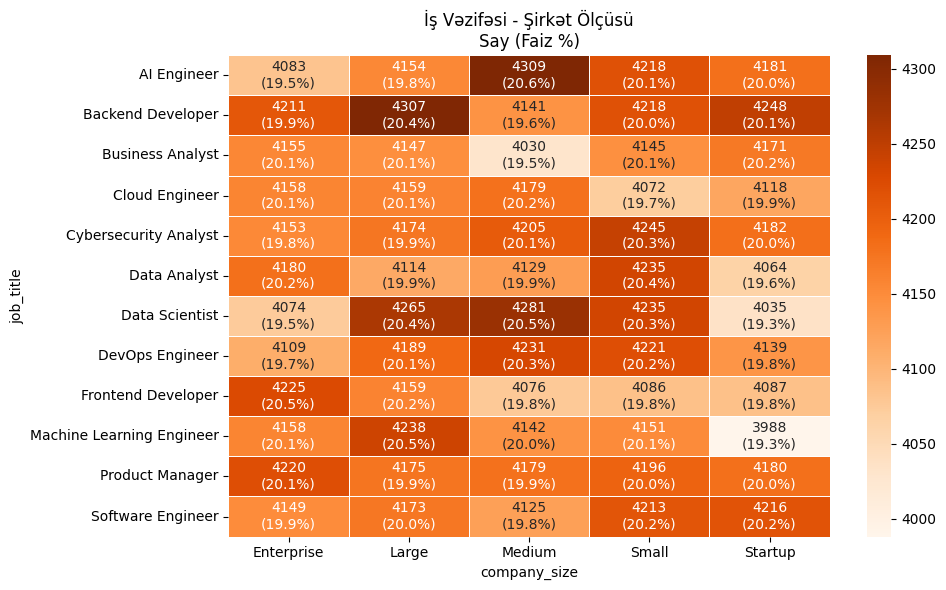


4. job_title ilə location analizi


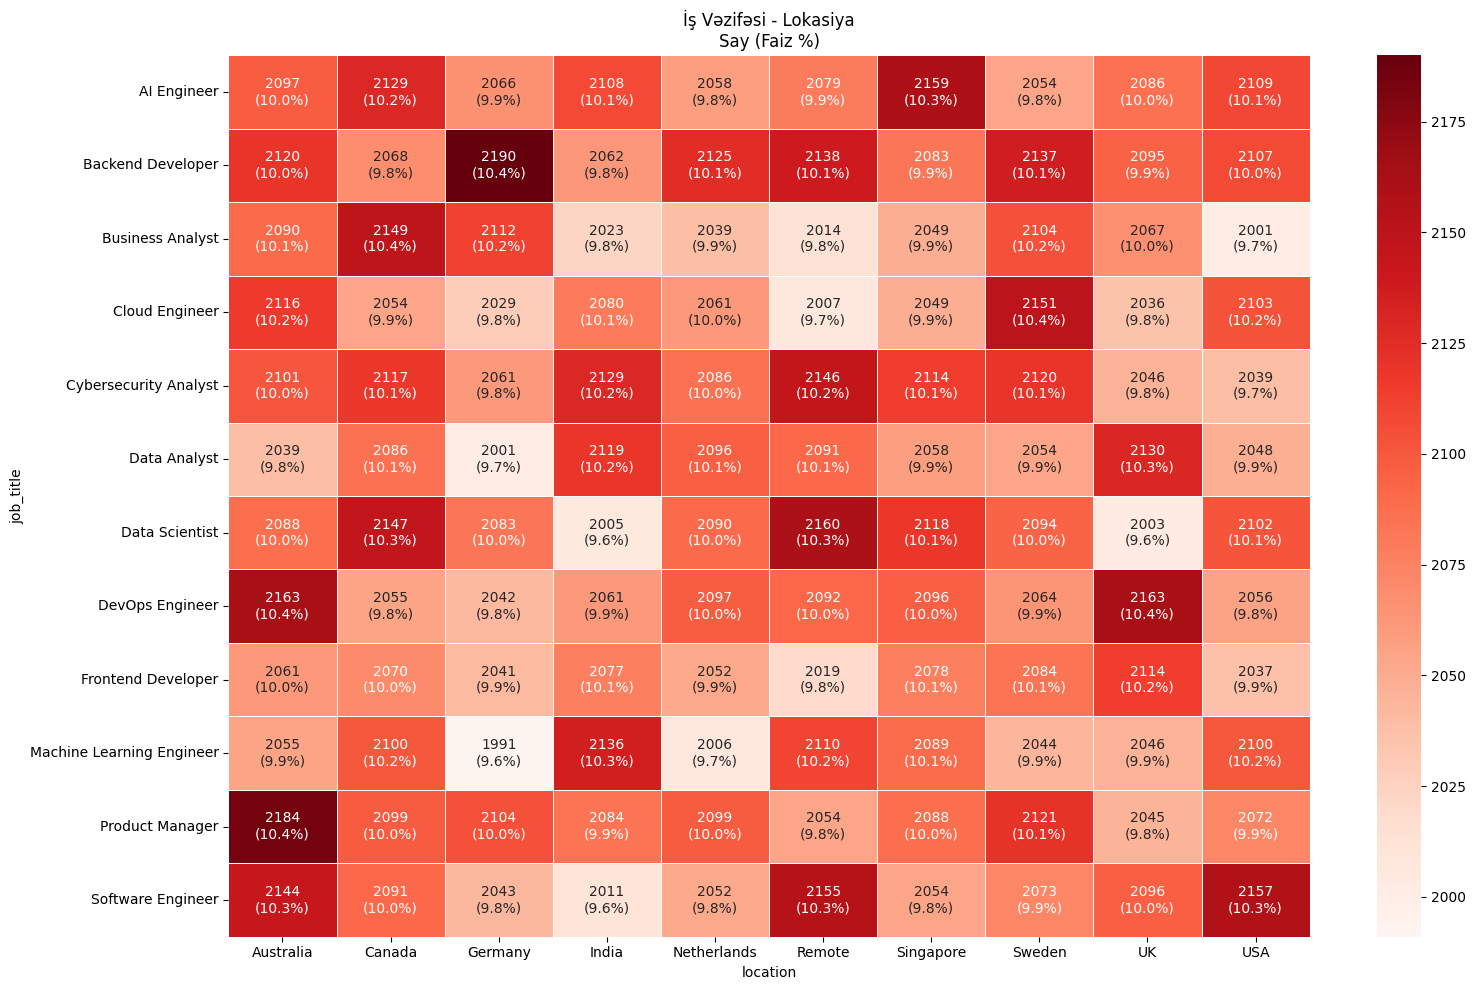


Maaş IQR (Ölkələr üzrə):
Australia: Median 137,754, IQR 39,375
Canada: Median 165,474, IQR 47,451
Sweden: Median 138,033, IQR 39,616
Remote: Median 137,836, IQR 39,479
Singapore: Median 137,699, IQR 39,708
USA: Median 179,647, IQR 51,228
UK: Median 158,191, IQR 45,567
India: Median 96,501, IQR 28,140
Netherlands: Median 137,356, IQR 40,142
Germany: Median 151,538, IQR 43,670

5. job_title ilə remote_work analizi


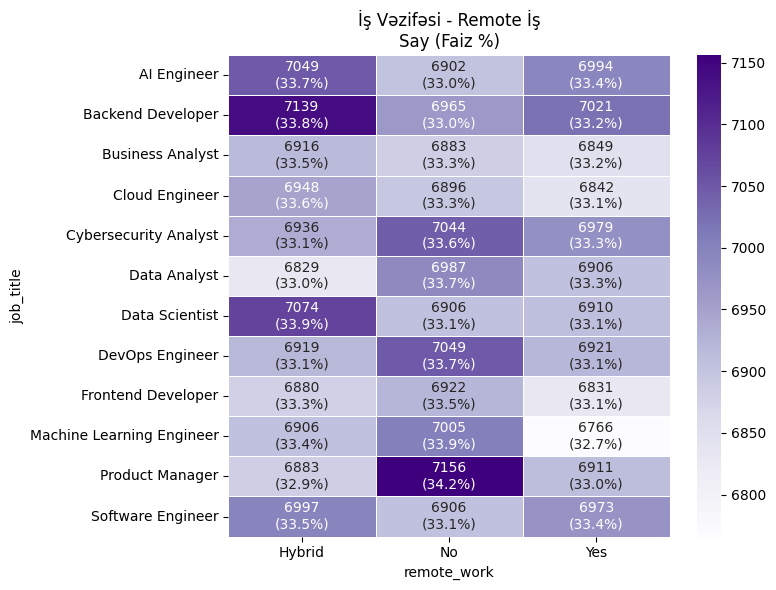


Maaş IQR:
Hybrid: Median 141,672, IQR 49,766
No: Median 141,630, IQR 49,936
Yes: Median 147,153, IQR 50,332

6. job_title ilə salary analizi


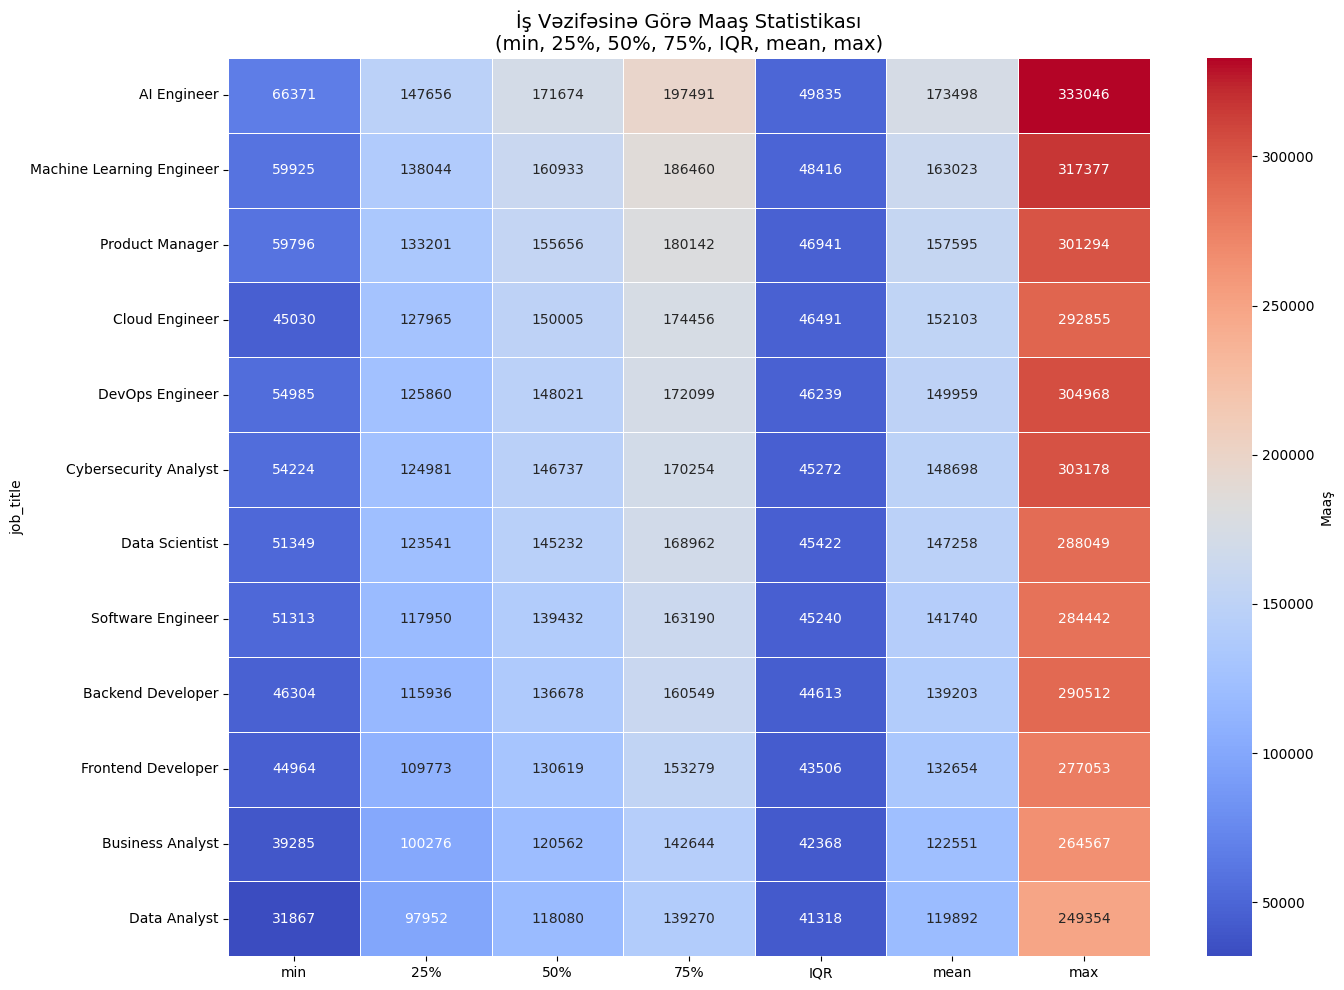

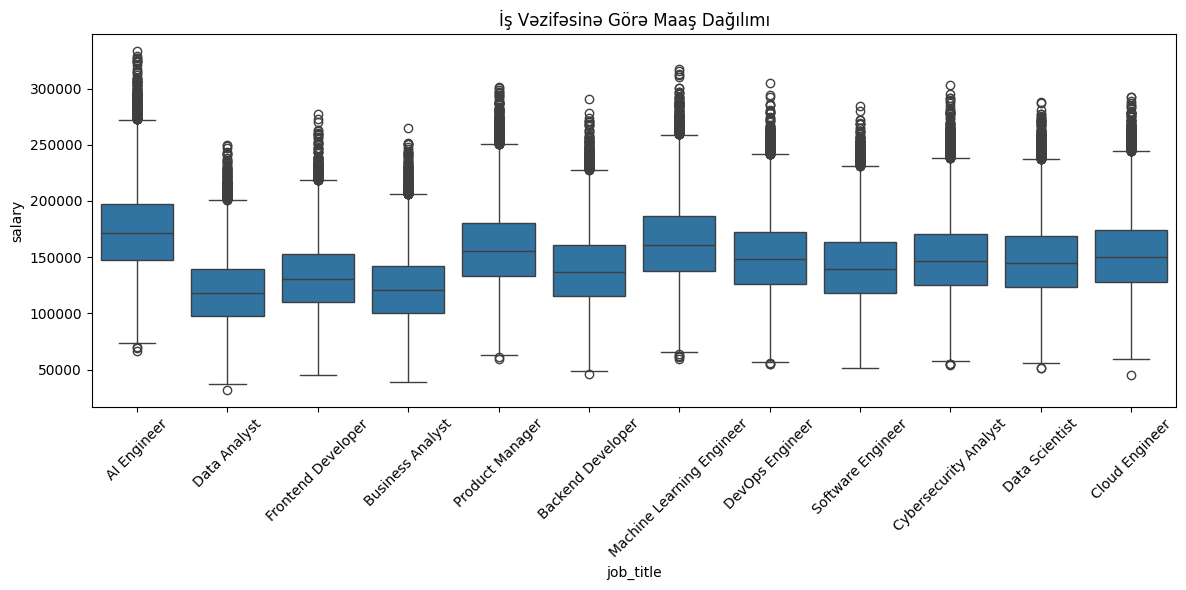

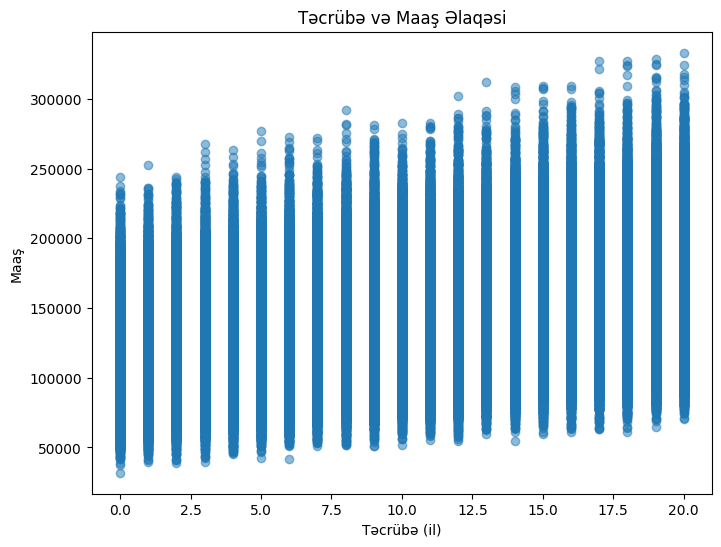

In [15]:
# Job_title analizi - Heatmap və statistika

# Maaş sütunu (əvvəldən təyin olunub)
salary_col = 'salary'
all_jobs = df['job_title'].value_counts().index
unique_jobs = df['job_title'].nunique()

print(f"Ümumi iş vəzifəsi sayı: {unique_jobs}")

# Statistika Heatmap

stats_data = []
for job in all_jobs:
    job_salary = df[df['job_title'] == job][salary_col].dropna()
    if len(job_salary) > 0:
        stats_data.append({
            'job_title': job,
            'min': job_salary.min(),
            '25%': job_salary.quantile(0.25),
            '50%': job_salary.median(),
            '75%': job_salary.quantile(0.75),
            'IQR': job_salary.quantile(0.75) - job_salary.quantile(0.25),
            'mean': job_salary.mean(),
            'max': job_salary.max()
        })

stats_df = pd.DataFrame(stats_data).set_index('job_title')

# 1. job_title ilə education_level analizi
if 'education_level' in df.columns:
    print("\n1. job_title ilə education_level analizi")
    
    edu_cross = pd.crosstab(df['job_title'], df['education_level'])
    edu_cross_pct = edu_cross.div(edu_cross.sum(axis=1), axis=0) * 100
    edu_annot = edu_cross.astype(str) + "\n(" + edu_cross_pct.round(1).astype(str) + "%)"
    
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.heatmap(edu_cross, annot=edu_annot.values, fmt='', cmap='Blues', linewidths=0.5, ax=ax)
    ax.set_title('İş Vəzifəsi - Təhsil Səviyyəsi\nSay (Faiz %)')
    plt.tight_layout()
    plt.show()

# 2. job_title ilə industry analizi
if 'industry' in df.columns:
    print("\n2. job_title ilə industry analizi")
    
    industry_cross = pd.crosstab(df['job_title'], df['industry'])
    industry_cross_pct = industry_cross.div(industry_cross.sum(axis=1), axis=0) * 100
    industry_annot = industry_cross.astype(str) + "\n(" + industry_cross_pct.round(1).astype(str) + "%)"
    
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.heatmap(industry_cross, annot=industry_annot.values, fmt='', cmap='Greens', linewidths=0.5, ax=ax)
    ax.set_title('İş Vəzifəsi - Sənaye\nSay (Faiz %)')
    plt.tight_layout()
    plt.show()

# 3. job_title ilə company_size analizi
if 'company_size' in df.columns:
    print("\n3. job_title ilə company_size analizi")
    
    size_cross = pd.crosstab(df['job_title'], df['company_size'])
    size_cross_pct = size_cross.div(size_cross.sum(axis=1), axis=0) * 100
    size_annot = size_cross.astype(str) + "\n(" + size_cross_pct.round(1).astype(str) + "%)"
    
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.heatmap(size_cross, annot=size_annot.values, fmt='', cmap='Oranges', linewidths=0.5, ax=ax)
    ax.set_title('İş Vəzifəsi - Şirkət Ölçüsü\nSay (Faiz %)')
    plt.tight_layout()
    plt.show()

# 4. job_title ilə location analizi (Top 20)
if 'location' in df.columns or 'country' in df.columns:
    location_col = 'location' if 'location' in df.columns else 'country'
    print("\n4. job_title ilə location analizi")
    
    top_locs = df[location_col].value_counts().head(20).index
    df_loc = df[df[location_col].isin(top_locs)]
    
    loc_cross = pd.crosstab(df_loc['job_title'], df_loc[location_col])
    loc_cross_pct = loc_cross.div(loc_cross.sum(axis=1), axis=0) * 100
    loc_annot = loc_cross.astype(str) + "\n(" + loc_cross_pct.round(1).astype(str) + "%)"
    
    fig, ax = plt.subplots(figsize=(16, 10))
    sns.heatmap(loc_cross, annot=loc_annot.values, fmt='', cmap='Reds', linewidths=0.5, ax=ax)
    ax.set_title('İş Vəzifəsi - Lokasiya\nSay (Faiz %)')
    plt.tight_layout()
    plt.show()
    
    if salary_col:
        print("\nMaaş IQR (Ölkələr üzrə):")
        for loc in top_locs:
            loc_salary = df[df[location_col] == loc][salary_col].dropna()
            if len(loc_salary) > 0:
                q1 = loc_salary.quantile(0.25)
                q3 = loc_salary.quantile(0.75)
                print(f"{loc}: Median {loc_salary.median():,.0f}, IQR {q3-q1:,.0f}")

# 5. job_title ilə remote_work analizi
if 'remote_work' in df.columns or 'remote' in df.columns:
    remote_col = 'remote_work' if 'remote_work' in df.columns else 'remote'
    print("\n5. job_title ilə remote_work analizi")
    
    remote_cross = pd.crosstab(df['job_title'], df[remote_col])
    remote_cross_pct = remote_cross.div(remote_cross.sum(axis=1), axis=0) * 100
    remote_annot = remote_cross.astype(str) + "\n(" + remote_cross_pct.round(1).astype(str) + "%)"
    
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(remote_cross, annot=remote_annot.values, fmt='', cmap='Purples', linewidths=0.5, ax=ax)
    ax.set_title('İş Vəzifəsi - Remote İş\nSay (Faiz %)')
    plt.tight_layout()
    plt.show()
    
    if salary_col:
        print("\nMaaş IQR:")
        for r_type in df[remote_col].unique():
            r_salary = df[df[remote_col] == r_type][salary_col].dropna()
            if len(r_salary) > 0:
                q1 = r_salary.quantile(0.25)
                q3 = r_salary.quantile(0.75)
                print(f"{r_type}: Median {r_salary.median():,.0f}, IQR {q3-q1:,.0f}")

# 6. job_title ilə salary analizi
if salary_col:
    print("\n6. job_title ilə salary analizi")
    
    # Statistika heatmap (bir dəfə yaradılan statistikadan istifadə)
    stats_sorted = stats_df.sort_values('mean', ascending=False)
    
    fig, ax = plt.subplots(figsize=(14, 10))
    sns.heatmap(stats_sorted, annot=True, fmt='.0f', cmap='coolwarm', linewidths=0.5, 
                cbar_kws={'label': 'Maaş'}, ax=ax)
    ax.set_title('İş Vəzifəsinə Görə Maaş Statistikası\n(min, 25%, 50%, 75%, IQR, mean, max)', fontsize=14)
    plt.tight_layout()
    plt.show()

    
    
    # Boxplot
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.boxplot(data=df, x='job_title', y=salary_col, ax=ax)
    ax.set_title('İş Vəzifəsinə Görə Maaş Dağılımı')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

# 7. experience_years ilə salary
correlation_matrix = df[['salary', 'experience_years']].corr()

# Scatter plot (qarşılıqlı əlaqə)
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df['experience_years'], df['salary'], alpha=0.5)
ax.set_xlabel('Təcrübə (il)')
ax.set_ylabel('Maaş')
ax.set_title('Təcrübə və Maaş Əlaqəsi')
plt.show()

In [16]:
df

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069
...,...,...,...,...,...,...,...,...,...,...
249995,Software Engineer,17,PhD,2,Telecom,Enterprise,India,No,1,127791
249996,Frontend Developer,20,PhD,7,Telecom,Startup,Remote,No,2,154593
249997,Business Analyst,1,Bachelor,12,Retail,Enterprise,India,Yes,0,75988
249998,Data Scientist,0,High School,2,Consulting,Small,Sweden,Hybrid,5,90467


## Outlier-lərə rəqəmsal baxış

In [17]:
# Hər vəzifə üzrə ortalama maaş
job_salary = df.groupby('job_title')['salary'].agg(['mean', 'median', 'count']).sort_values('mean', ascending=False)

print("Ən Yüksək maaşlı vəzifələr - 5 vəzifə:")
print(job_salary.head())

print("\nƏn aşağı maaşlı vəzifələr - 5 vəzifə:")
print(job_salary.tail())

Ən Yüksək maaşlı vəzifələr - 5 vəzifə:
                                    mean    median  count
job_title                                                
AI Engineer                173498.480640  171674.0  20945
Machine Learning Engineer  163022.504570  160933.0  20677
Product Manager            157594.932029  155655.5  20950
Cloud Engineer             152102.535290  150005.0  20686
DevOps Engineer            149959.266791  148021.0  20889

Ən aşağı maaşlı vəzifələr - 5 vəzifə:
                             mean    median  count
job_title                                         
Software Engineer   141739.521460  139432.5  20876
Backend Developer   139202.768663  136678.0  21125
Frontend Developer  132653.842485  130619.0  20633
Business Analyst    122551.231354  120562.0  20648
Data Analyst        119891.696603  118079.5  20722


# Model Qurulması

In [18]:
# Məlumat Hazırlığı

salary_col = 'salary'

# 1. Hədəf dəyişənlər
y_reg = df['salary']
median_salary = df['salary'].median()
y_class = (df['salary'] > median_salary).astype(int)

print(f"Median maaş: {median_salary:,.0f}")
print(f"\nKlassifikasiya Targeti:")
print(f"  Sinif 0 (Aşağı maaş ≤ {median_salary:,.0f}): {(y_class == 0).sum():,} ({(y_class == 0).mean()*100:.1f}%)")
print(f"  Sinif 1 (Yüksək maaş > {median_salary:,.0f}): {(y_class == 1).sum():,} ({(y_class == 1).mean()*100:.1f}%)")

print(f"\nReqresiya Targeti:")
print(f"  Diapazon: {y_reg.min():,.0f} - {y_reg.max():,.0f}")
print(f"  Ortalama: {y_reg.mean():,.0f}")
print(f"  Median: {y_reg.median():,.0f}")

# X-dən yalnız salary sütununu çıxar (salary_log və salary_level yoxdur)
X = df.drop(columns=[salary_col])

print(f"X-dəki sütunlar ({len(X.columns)} ədəd):")
for i, col in enumerate(X.columns, 1):
    print(f"  {i:2}. {col}")

print("Kateqorik dəyərlərin encoding edilməsi")
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Kateqorik sütunlar: {categorical_cols}")

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    print(f"  • {col} → encode edildi")

# NaN-ları təmizlə
X = X.fillna(X.median())

# Train-Test Split
print("TRAIN-TEST SPLIT")
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X, y_class, test_size=0.2, random_state=42, stratify=y_class
)

print(f"Train set: {X_train_reg.shape[0]:,}")
print(f"Test set: {X_test_reg.shape[0]:,}")

Median maaş: 143,453

Klassifikasiya Targeti:
  Sinif 0 (Aşağı maaş ≤ 143,453): 125,003 (50.0%)
  Sinif 1 (Yüksək maaş > 143,453): 124,997 (50.0%)

Reqresiya Targeti:
  Diapazon: 31,867 - 333,046
  Ortalama: 145,718
  Median: 143,453
X-dəki sütunlar (9 ədəd):
   1. job_title
   2. experience_years
   3. education_level
   4. skills_count
   5. industry
   6. company_size
   7. location
   8. remote_work
   9. certifications
Kateqorik dəyərlərin encoding edilməsi
Kateqorik sütunlar: ['job_title', 'education_level', 'industry', 'company_size', 'location', 'remote_work']
  • job_title → encode edildi
  • education_level → encode edildi
  • industry → encode edildi
  • company_size → encode edildi
  • location → encode edildi
  • remote_work → encode edildi
TRAIN-TEST SPLIT
Train set: 200,000
Test set: 50,000


1. Random Forest Reqresiya
MAE: 5,184
RMSE: 6,557
R²: 0.9691
MAPE: 3.77%

Cross-validation R² (5-fold): 0.9693 (+/- 0.0001)


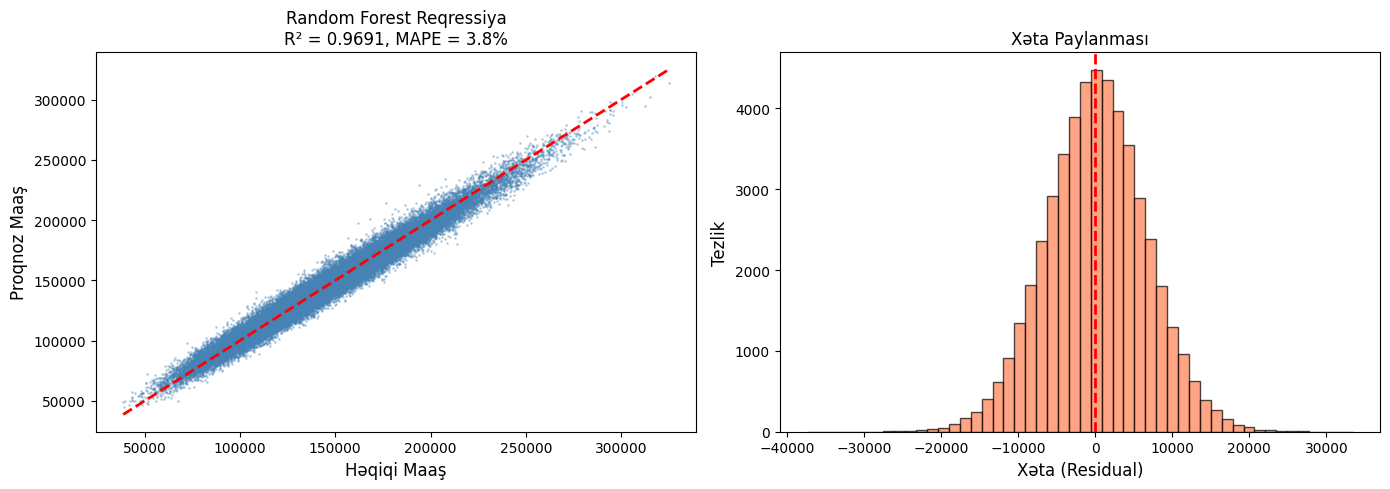


Feature İmport - Random Forest Reqressiya:
--------------------------------------------------
Feature                         Əhəmiyyət
--------------------------------------------------
location                           0.3293
experience_years                   0.1986
company_size                       0.1687
job_title                          0.1582
education_level                    0.0977
skills_count                       0.0254
certifications                     0.0096
industry                           0.0069
remote_work                        0.0056


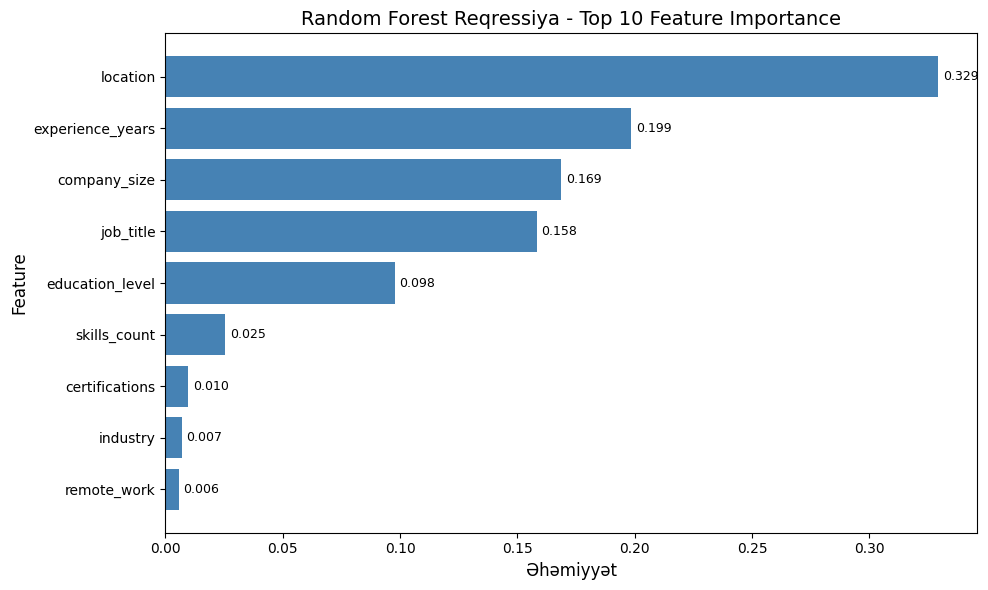

In [19]:
print("1. Random Forest Reqresiya")

# Model qur
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_reg.fit(X_train_reg, y_train_reg)

# Proqnoz
y_pred_reg = rf_reg.predict(X_test_reg)

# Qiymətləndirmə
mae = mean_absolute_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
r2 = r2_score(y_test_reg, y_pred_reg)
mape = (np.abs((y_test_reg - y_pred_reg) / y_test_reg).mean() * 100)

print(f"MAE: {mae:,.0f}")
print(f"RMSE: {rmse:,.0f}")
print(f"R²: {r2:.4f}")
print(f"MAPE: {mape:.2f}%")

# Cross-validation
cv_scores = cross_val_score(rf_reg, X, y_reg, cv=5, scoring='r2', n_jobs=-1)
print(f"\nCross-validation R² (5-fold): {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# Qrafiklər
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Həqiqi vs Proqnoz
axes[0].scatter(y_test_reg, y_pred_reg, alpha=0.3, s=1, color='steelblue')
axes[0].plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
axes[0].set_xlabel('Həqiqi Maaş', fontsize=12)
axes[0].set_ylabel('Proqnoz Maaş', fontsize=12)
axes[0].set_title(f'Random Forest Reqressiya\nR² = {r2:.4f}, MAPE = {mape:.1f}%', fontsize=12)

# Residuals
residuals = y_test_reg - y_pred_reg
axes[1].hist(residuals, bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[1].axvline(0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Xəta (Residual)', fontsize=12)
axes[1].set_ylabel('Tezlik', fontsize=12)
axes[1].set_title('Xəta Paylanması', fontsize=12)

plt.tight_layout()
plt.show()

# Feature Importance
rf_reg_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_reg.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature İmport - Random Forest Reqressiya:")
print("-"*50)
print(f"{'Feature':<25} {'Əhəmiyyət':>15}")
print("-"*50)
for _, row in rf_reg_importance.head(10).iterrows():
    print(f"{row['feature']:<25} {row['importance']:>15.4f}")

# Feature Importance qrafiki
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(rf_reg_importance.head(10)['feature'], rf_reg_importance.head(10)['importance'], color='steelblue')
ax.set_xlabel('Əhəmiyyət', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)
ax.set_title('Random Forest Reqressiya - Top 10 Feature Importance', fontsize=14)
ax.invert_yaxis()

for i, (idx, row) in enumerate(rf_reg_importance.head(10).iterrows()):
    ax.text(row['importance'] + 0.002, i, f'{row["importance"]:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

2. RandomForest Klassifikasiya
Accuracy: 0.9350
Precision: 0.9356
Recall: 0.9343
F1-Score: 0.9349

Cross-validation Accuracy (5-fold): 0.9343 (+/- 0.0011)

Classification Report:
              precision    recall  f1-score   support

  Aşağı Maaş       0.93      0.94      0.94     25001
 Yüksək Maaş       0.94      0.93      0.93     24999

    accuracy                           0.93     50000
   macro avg       0.93      0.93      0.93     50000
weighted avg       0.93      0.93      0.93     50000



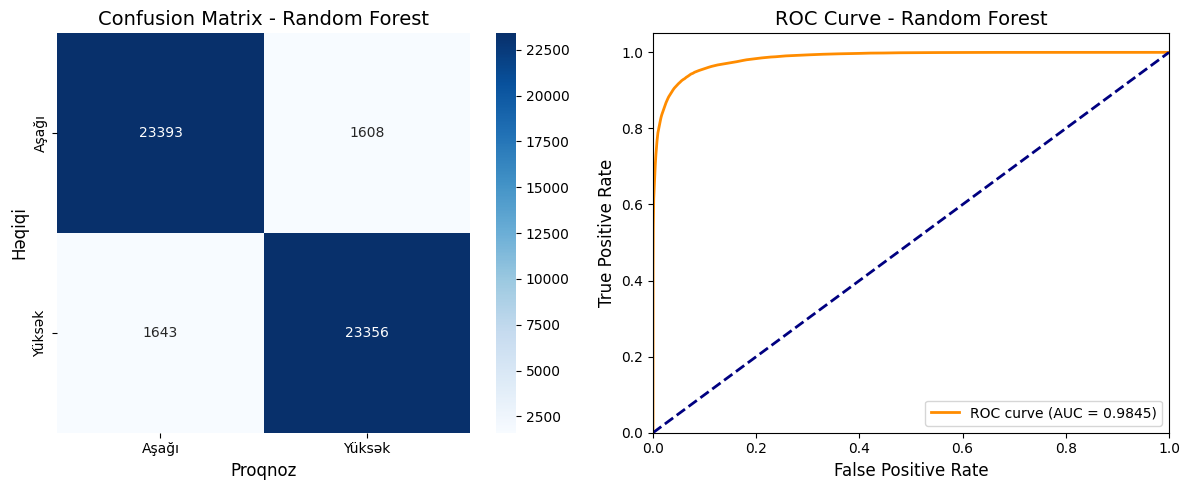


Feature İmortance - Random Forest Klasifikasiya:
--------------------------------------------------
Feature                         Əhəmiyyət
--------------------------------------------------
location                           0.2506
experience_years                   0.1886
job_title                          0.1639
company_size                       0.1287
education_level                    0.0889
skills_count                       0.0682
industry                           0.0482
certifications                     0.0394
remote_work                        0.0236


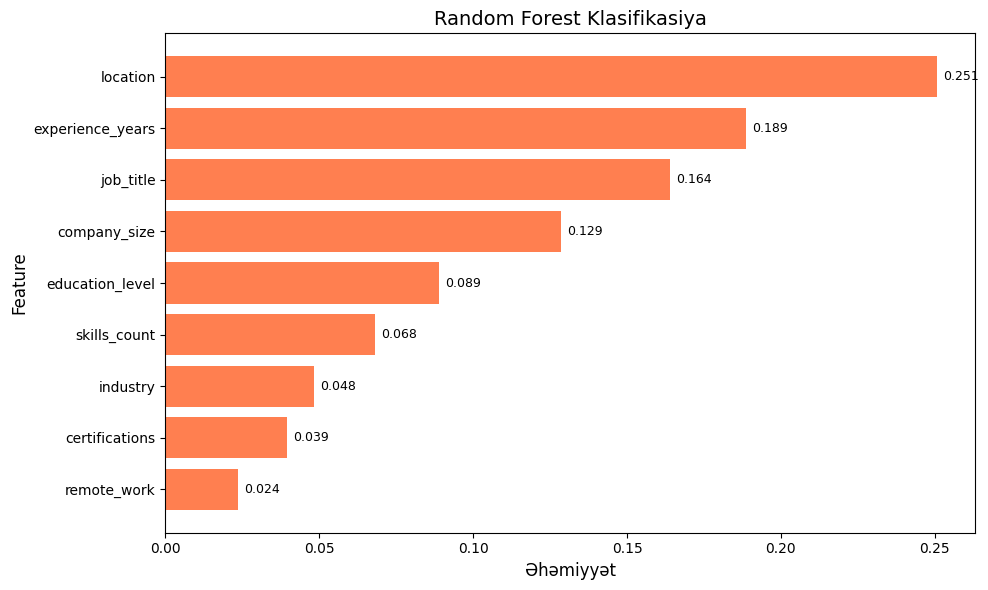

In [20]:
print("2. RandomForest Klassifikasiya")

# Model qur
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced')
rf_clf.fit(X_train_clf, y_train_clf)

# Proqnoz
y_pred_clf = rf_clf.predict(X_test_clf)
y_proba = rf_clf.predict_proba(X_test_clf)[:, 1]

# Qiymətləndirmə
accuracy = accuracy_score(y_test_clf, y_pred_clf)
precision = precision_score(y_test_clf, y_pred_clf)
recall = recall_score(y_test_clf, y_pred_clf)
f1 = f1_score(y_test_clf, y_pred_clf)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Cross-validation
cv_scores_clf = cross_val_score(rf_clf, X, y_class, cv=5, scoring='accuracy', n_jobs=-1)
print(f"\nCross-validation Accuracy (5-fold): {cv_scores_clf.mean():.4f} (+/- {cv_scores_clf.std():.4f})")

print("\nClassification Report:")
print(classification_report(y_test_clf, y_pred_clf, target_names=['Aşağı Maaş', 'Yüksək Maaş']))

# Qrafiklər
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion Matrix
cm = confusion_matrix(y_test_clf, y_pred_clf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Aşağı', 'Yüksək'], 
            yticklabels=['Aşağı', 'Yüksək'],
            ax=axes[0])
axes[0].set_title('Confusion Matrix - Random Forest', fontsize=14)
axes[0].set_xlabel('Proqnoz', fontsize=12)
axes[0].set_ylabel('Həqiqi', fontsize=12)

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test_clf, y_proba)
auc = roc_auc_score(y_test_clf, y_proba)

axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].set_title('ROC Curve - Random Forest', fontsize=14)
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

# Feature Importance
rf_clf_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_clf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature İmortance - Random Forest Klasifikasiya:")
print("-"*50)
print(f"{'Feature':<25} {'Əhəmiyyət':>15}")
print("-"*50)
for _, row in rf_clf_importance.head(10).iterrows():
    print(f"{row['feature']:<25} {row['importance']:>15.4f}")

# Feature Importance qrafiki
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(rf_clf_importance.head(12)['feature'], rf_clf_importance.head(12)['importance'], color='coral')
ax.set_xlabel('Əhəmiyyət', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)
ax.set_title('Random Forest Klasifikasiya', fontsize=14)
ax.invert_yaxis()

for i, (idx, row) in enumerate(rf_clf_importance.head(10).iterrows()):
    ax.text(row['importance'] + 0.002, i, f'{row["importance"]:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

1. XGBoost Reqresiya
MAE: 4,395
RMSE: 5,507
R²: 0.9782
MAPE: 3.24%

Cross-validation R² (5-fold): 0.9782 (+/- 0.0001)


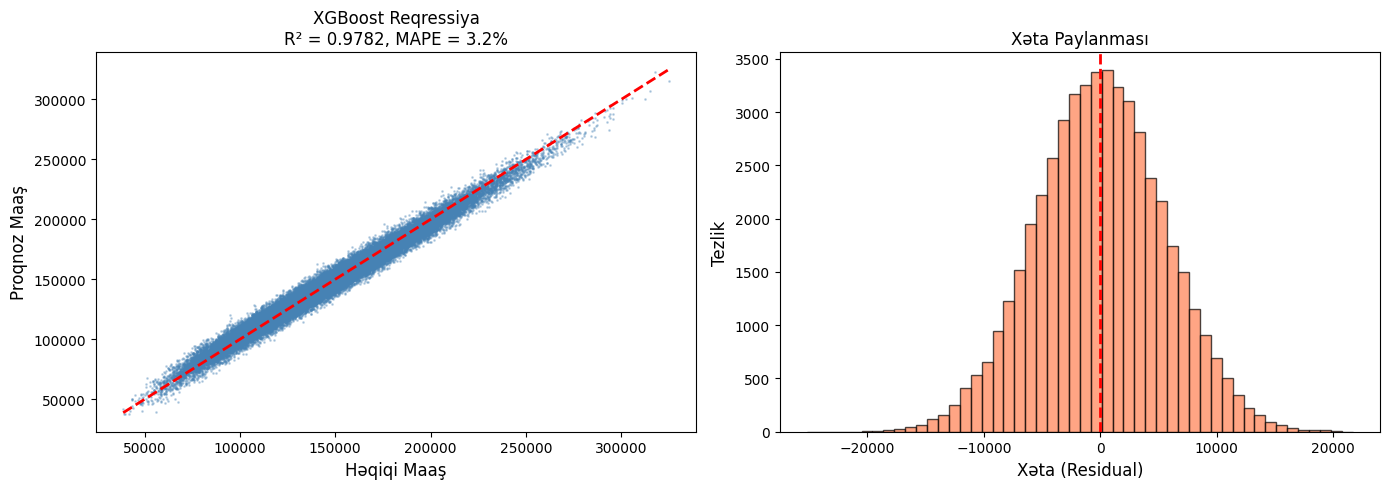


Feature İmportance - XGBoost Reqressiya:
-------------------------------------------------------
Feature                              Əhəmiyyət
-------------------------------------------------------
company_size                            0.2942
experience_years                        0.2351
location                                0.1921
education_level                         0.1306
job_title                               0.0868
skills_count                            0.0269
remote_work                             0.0202
certifications                          0.0140
industry                                0.0001


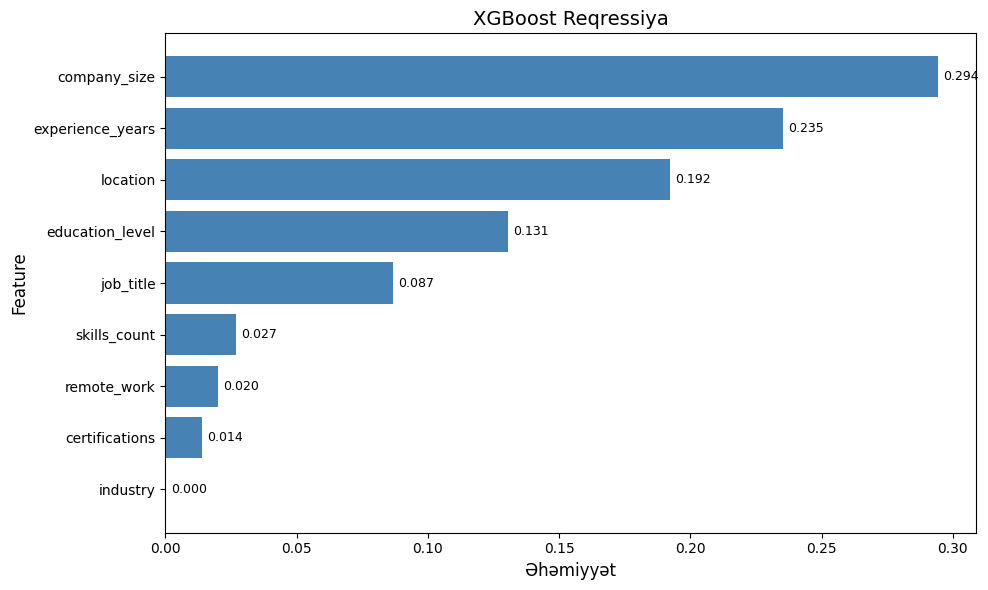

In [23]:
print("1. XGBoost Reqresiya")

# Model qur
xgb_reg = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

xgb_reg.fit(X_train_reg, y_train_reg)

# Proqnoz
y_pred_reg = xgb_reg.predict(X_test_reg)

# Qiymətləndirmə
mae = mean_absolute_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
r2 = r2_score(y_test_reg, y_pred_reg)
mape = (np.abs((y_test_reg - y_pred_reg) / y_test_reg).mean() * 100)

print(f"MAE: {mae:,.0f}")
print(f"RMSE: {rmse:,.0f}")
print(f"R²: {r2:.4f}")
print(f"MAPE: {mape:.2f}%")

# Cross-validation
cv_scores = cross_val_score(xgb_reg, X, y_reg, cv=5, scoring='r2', n_jobs=-1)
print(f"\nCross-validation R² (5-fold): {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# Qrafiklər
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Həqiqi vs Proqnoz
axes[0].scatter(y_test_reg, y_pred_reg, alpha=0.3, s=1, color='steelblue')
axes[0].plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
axes[0].set_xlabel('Həqiqi Maaş', fontsize=12)
axes[0].set_ylabel('Proqnoz Maaş', fontsize=12)
axes[0].set_title(f'XGBoost Reqressiya\nR² = {r2:.4f}, MAPE = {mape:.1f}%', fontsize=12)

# Residuals
residuals = y_test_reg - y_pred_reg
axes[1].hist(residuals, bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[1].axvline(0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Xəta (Residual)', fontsize=12)
axes[1].set_ylabel('Tezlik', fontsize=12)
axes[1].set_title('Xəta Paylanması', fontsize=12)

plt.tight_layout()
plt.show()

# Feature Importance
xgb_reg_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_reg.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature İmportance - XGBoost Reqressiya:")
print("-"*55)
print(f"{'Feature':<25} {'Əhəmiyyət':>20}")
print("-"*55)
for _, row in xgb_reg_importance.head(10).iterrows():
    print(f"{row['feature']:<25} {row['importance']:>20.4f}")

# Feature Importance qrafiki
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(xgb_reg_importance.head(10)['feature'], xgb_reg_importance.head(10)['importance'], color='steelblue')
ax.set_xlabel('Əhəmiyyət', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)
ax.set_title('XGBoost Reqressiya', fontsize=14)
ax.invert_yaxis()

for i, (idx, row) in enumerate(xgb_reg_importance.head(12).iterrows()):
    ax.text(row['importance'] + 0.002, i, f'{row["importance"]:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

2. XGBoost Klassifikasiya
Accuracy: 0.9469
Precision: 0.9504
Recall: 0.9431
F1-Score: 0.9467

Cross-validation Accuracy (5-fold): 0.9478 (+/- 0.0012)

Classification Report:
              precision    recall  f1-score   support

  Aşağı Maaş       0.94      0.95      0.95     25001
 Yüksək Maaş       0.95      0.94      0.95     24999

    accuracy                           0.95     50000
   macro avg       0.95      0.95      0.95     50000
weighted avg       0.95      0.95      0.95     50000



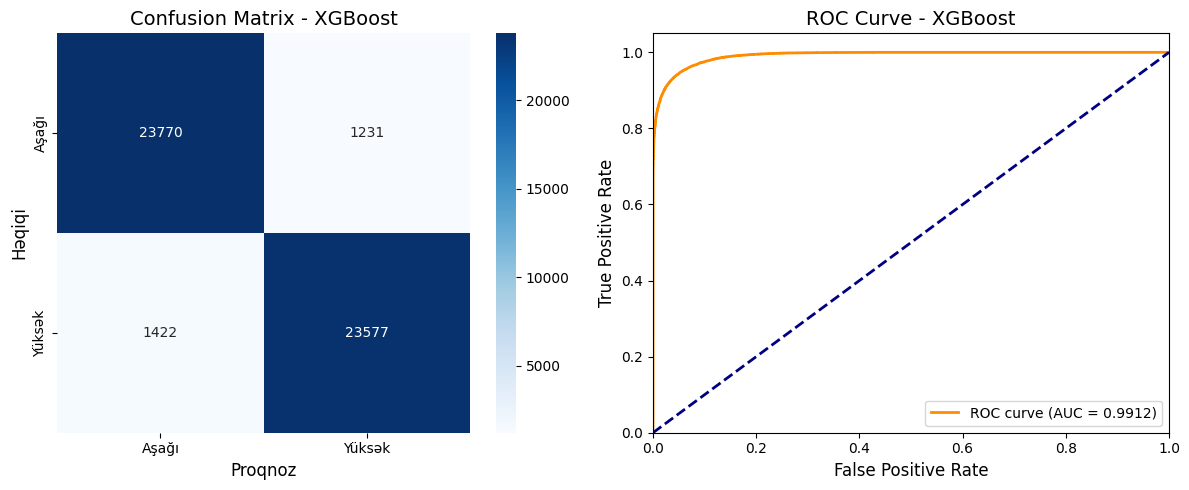


Feature İmportance - XGBoost Klasifikasiya:
-------------------------------------------------------
Feature                              Əhəmiyyət
-------------------------------------------------------
experience_years                        0.1857
company_size                            0.1835
location                                0.1473
job_title                               0.1339
education_level                         0.1253
remote_work                             0.1067
skills_count                            0.0590
certifications                          0.0570
industry                                0.0017


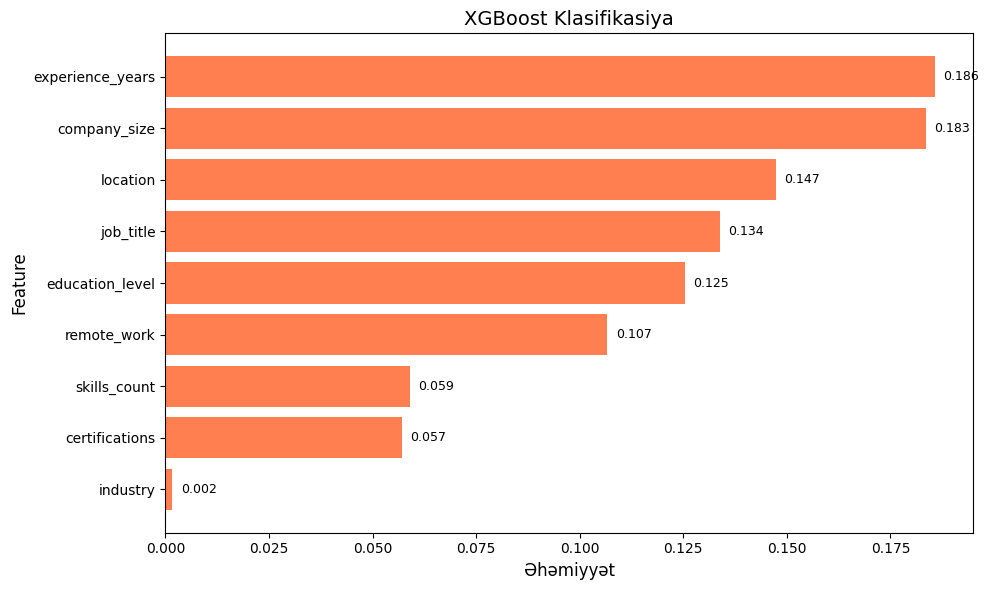

In [24]:
print("2. XGBoost Klassifikasiya")

# Model qur
xgb_clf = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=1  # Siniflər balanslı olduğu üçün
)

xgb_clf.fit(X_train_clf, y_train_clf)

# Proqnoz
y_pred_clf = xgb_clf.predict(X_test_clf)
y_proba = xgb_clf.predict_proba(X_test_clf)[:, 1]

# Qiymətləndirmə
accuracy = accuracy_score(y_test_clf, y_pred_clf)
precision = precision_score(y_test_clf, y_pred_clf)
recall = recall_score(y_test_clf, y_pred_clf)
f1 = f1_score(y_test_clf, y_pred_clf)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Cross-validation
cv_scores_clf = cross_val_score(xgb_clf, X, y_class, cv=5, scoring='accuracy', n_jobs=-1)
print(f"\nCross-validation Accuracy (5-fold): {cv_scores_clf.mean():.4f} (+/- {cv_scores_clf.std():.4f})")

print("\nClassification Report:")
print(classification_report(y_test_clf, y_pred_clf, target_names=['Aşağı Maaş', 'Yüksək Maaş']))

# Qrafiklər
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion Matrix
cm = confusion_matrix(y_test_clf, y_pred_clf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Aşağı', 'Yüksək'], 
            yticklabels=['Aşağı', 'Yüksək'],
            ax=axes[0])
axes[0].set_title('Confusion Matrix - XGBoost', fontsize=14)
axes[0].set_xlabel('Proqnoz', fontsize=12)
axes[0].set_ylabel('Həqiqi', fontsize=12)

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test_clf, y_proba)
auc = roc_auc_score(y_test_clf, y_proba)

axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].set_title('ROC Curve - XGBoost', fontsize=14)
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

# Feature Importance
xgb_clf_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_clf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature İmportance - XGBoost Klasifikasiya:")
print("-"*55)
print(f"{'Feature':<25} {'Əhəmiyyət':>20}")
print("-"*55)
for _, row in xgb_clf_importance.head(10).iterrows():
    print(f"{row['feature']:<25} {row['importance']:>20.4f}")

# Feature Importance qrafiki
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(xgb_clf_importance.head(12)['feature'], xgb_clf_importance.head(12)['importance'], color='coral')
ax.set_xlabel('Əhəmiyyət', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)
ax.set_title('XGBoost Klasifikasiya', fontsize=14)
ax.invert_yaxis()

for i, (idx, row) in enumerate(xgb_clf_importance.head(12).iterrows()):
    ax.text(row['importance'] + 0.002, i, f'{row["importance"]:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [25]:
print("3. Random Forest vs XGBoost Müqayisəsi")

# Random Forest nəticələri (əvvəlki kodda işlədilibsə)
# Əgər yoxdursa, Random Forest nəticələrini burada yenidən hesablayaq

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

# Random Forest Reqressiya
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_reg.fit(X_train_reg, y_train_reg)
y_pred_rf_reg = rf_reg.predict(X_test_reg)
rf_r2 = r2_score(y_test_reg, y_pred_rf_reg)
rf_mae = mean_absolute_error(y_test_reg, y_pred_rf_reg)
rf_mape = (np.abs((y_test_reg - y_pred_rf_reg) / y_test_reg).mean() * 100)

# Random Forest Klasifikasiya
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced')
rf_clf.fit(X_train_clf, y_train_clf)
y_pred_rf_clf = rf_clf.predict(X_test_clf)
rf_accuracy = accuracy_score(y_test_clf, y_pred_rf_clf)
rf_precision = precision_score(y_test_clf, y_pred_rf_clf)
rf_recall = recall_score(y_test_clf, y_pred_rf_clf)
rf_f1 = f1_score(y_test_clf, y_pred_rf_clf)

print("\nReqresiya Müqayisəsi:")
print(f"{'Metrik':<15} {'Random Forest':>20} {'XGBoost':>20}")
print(f"{'R²':<15} {rf_r2:>20.4f} {r2:>20.4f}")
print(f"{'MAE':<15} {rf_mae:>20,.0f} {mae:>20,.0f}")
print(f"{'MAPE':<15} {rf_mape:>19.1f}% {mape:>19.1f}%")

print("\nKlassifikasiya Müqayisəsi:")
print(f"{'Metrik':<15} {'Random Forest':>20} {'XGBoost':>20}")
print(f"{'Accuracy':<15} {rf_accuracy:>20.4f} {accuracy:>20.4f}")
print(f"{'Precision':<15} {rf_precision:>20.4f} {precision:>20.4f}")
print(f"{'Recall':<15} {rf_recall:>20.4f} {recall:>20.4f}")
print(f"{'F1':<15} {rf_f1:>20.4f} {f1:>20.4f}")

# ROC AUC müqayisəsi
rf_proba = rf_clf.predict_proba(X_test_clf)[:, 1]
rf_auc = roc_auc_score(y_test_clf, rf_proba)
print(f"\n{'AUC':<15} {rf_auc:>20.4f} {auc:>20.4f}")

3. Random Forest vs XGBoost Müqayisəsi

Reqresiya Müqayisəsi:
Metrik                 Random Forest              XGBoost
R²                            0.9691               0.9782
MAE                            5,184                4,395
MAPE                            3.8%                 3.2%

Klassifikasiya Müqayisəsi:
Metrik                 Random Forest              XGBoost
Accuracy                      0.9350               0.9469
Precision                     0.9356               0.9504
Recall                        0.9343               0.9431
F1                            0.9349               0.9467

AUC                           0.9845               0.9912


4. Feature İmportance müqayisəsi

 Features (XGBoost Reqressiya sırası ilə):
Feature                       XGBoost_Reg RandomForest_Reg
company_size                       0.2942          0.1687
experience_years                   0.2351          0.1986
location                           0.1921          0.3293
education_level                    0.1306          0.0977
job_title                          0.0868          0.1582
skills_count                       0.0269          0.0254
remote_work                        0.0202          0.0056
certifications                     0.0140          0.0096
industry                           0.0001          0.0069


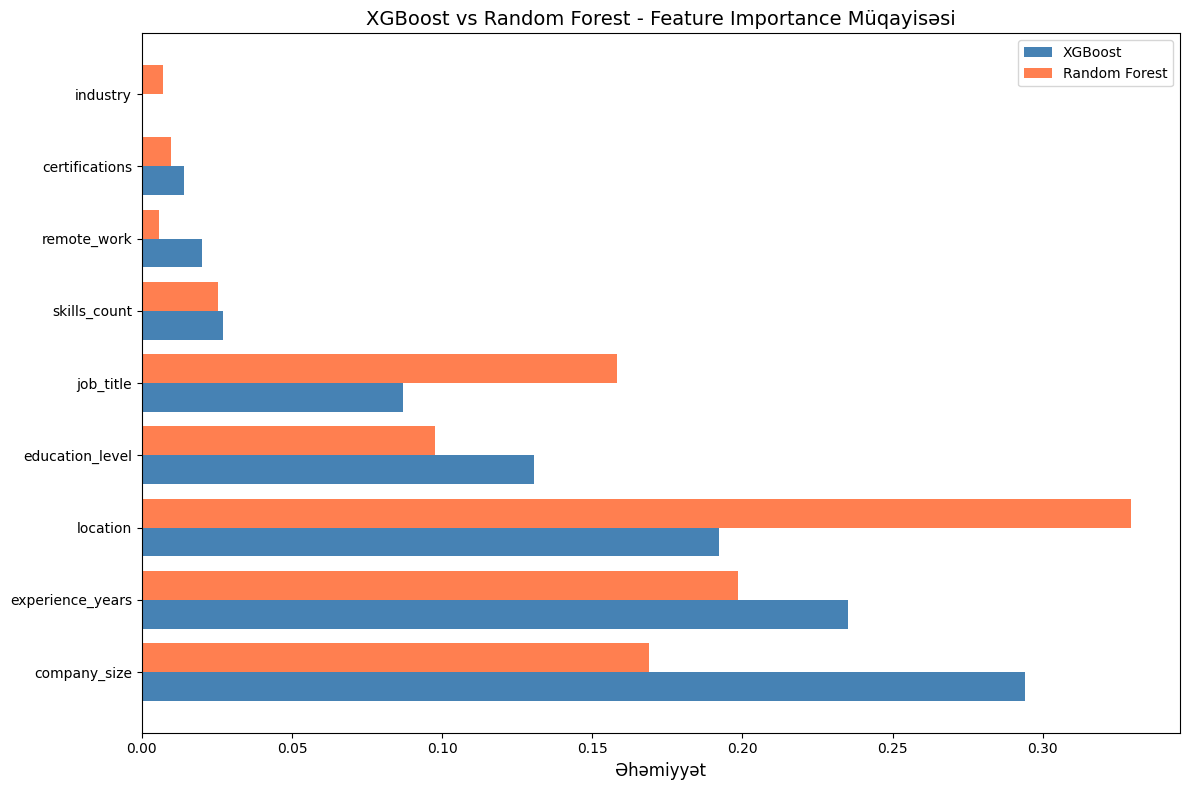

In [26]:
print("4. Feature İmportance müqayisəsi")

# Hər iki modelin feature importance-larını birləşdir
comparison_imp = xgb_reg_importance.merge(rf_reg_importance, on='feature', how='outer').fillna(0)
comparison_imp.columns = ['feature', 'XGBoost_Reg', 'RandomForest_Reg']
comparison_imp = comparison_imp.sort_values('XGBoost_Reg', ascending=False)

print("\n Features (XGBoost Reqressiya sırası ilə):")
print(f"{'Feature':<25} {'XGBoost_Reg':>15} {'RandomForest_Reg':>15}")
for _, row in comparison_imp.head(10).iterrows():
    print(f"{row['feature']:<25} {row['XGBoost_Reg']:>15.4f} {row['RandomForest_Reg']:>15.4f}")

# Müqayisə qrafiki
fig, ax = plt.subplots(figsize=(12, 8))

y_pos = np.arange(len(comparison_imp.head(12)))
ax.barh(y_pos - 0.2, comparison_imp.head(12)['XGBoost_Reg'], height=0.4, label='XGBoost', color='steelblue')
ax.barh(y_pos + 0.2, comparison_imp.head(12)['RandomForest_Reg'], height=0.4, label='Random Forest', color='coral')

ax.set_yticks(y_pos)
ax.set_yticklabels(comparison_imp.head(12)['feature'])
ax.set_xlabel('Əhəmiyyət', fontsize=12)
ax.set_title('XGBoost vs Random Forest - Feature Importance Müqayisəsi', fontsize=14)
ax.legend()
plt.tight_layout()
plt.show()

In [27]:
print("5. YEKUN NƏTİCƏ")

print(f"""
                    XGBOOST REQRESSİYA                           

  R² = {r2:.4f}                                                  
  MAE = {mae:,.0f} AZN                                          
  MAPE = {mape:.1f}%                                             
  CV R² = {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})     
                                                                  
  {'Random Forest-dən Daha Yaxşı' if r2 > rf_r2 else 'Random Forest ilə eyni'}     

                    XGBOOST KLASİFİKASİYA                         

  Accuracy = {accuracy:.4f}                                      
  Precision = {precision:.4f}                                    
  Recall = {recall:.4f}                                          
  F1 = {f1:.4f}                                                  
  AUC = {auc:.4f}                                                
  CV Accuracy = {cv_scores_clf.mean():.4f} (+/- {cv_scores_clf.std():.4f}) 
                                                                  │
  {'Random Forest-dən Daha Yaxşı' if accuracy > rf_accuracy else 'Random Forest ilə eyni'} │

 
""")

# Hansı model daha yaxşı?
best_reg = "XGBoost" if r2 > rf_r2 else "Random Forest"
best_clf = "XGBoost" if accuracy > rf_accuracy else "Random Forest"

print(f"\n ƏN YAXŞI MODEL:")
print(f"   • Reqressiya və Klassifikasiya üçün: {best_reg}, {best_clf}")

5. YEKUN NƏTİCƏ

                    XGBOOST REQRESSİYA                           

  R² = 0.9782                                                  
  MAE = 4,395 AZN                                          
  MAPE = 3.2%                                             
  CV R² = 0.9782 (+/- 0.0001)     
                                                                  
  Random Forest-dən Daha Yaxşı     

                    XGBOOST KLASİFİKASİYA                         

  Accuracy = 0.9469                                      
  Precision = 0.9504                                    
  Recall = 0.9431                                          
  F1 = 0.9467                                                  
  AUC = 0.9912                                                
  CV Accuracy = 0.9478 (+/- 0.0012) 
                                                                  │
  Random Forest-dən Daha Yaxşı │

 


 ƏN YAXŞI MODEL:
   • Reqressiya və Klassifikasiya üçün: XGBoost, XGBoost


In [28]:
from sklearn.model_selection import GridSearchCV

# XGBoost üçün hiperparametr axtarışı
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0]
}

grid_search = GridSearchCV(
    xgb.XGBRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_reg, y_train_reg)
print(f"Ən yaxşı parametrlər: {grid_search.best_params_}")
print(f"Ən yaxşı R²: {grid_search.best_score_:.4f}")

Fitting 3 folds for each of 54 candidates, totalling 162 fits
Ən yaxşı parametrlər: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 300, 'subsample': 0.8}
Ən yaxşı R²: 0.9802


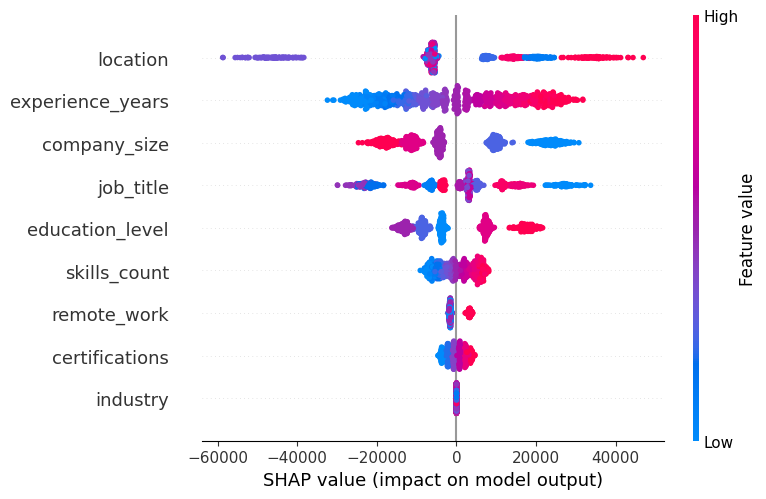

In [29]:
import shap

# SHAP analizi
explainer = shap.TreeExplainer(xgb_reg)
shap_values = explainer.shap_values(X_test_reg[:1000])

# Qrafik
shap.summary_plot(shap_values, X_test_reg[:1000], feature_names=X.columns)

In [30]:
import joblib

# Modeli saxla
joblib.dump(xgb_reg, 'xgb_reg_model.pkl')
joblib.dump(xgb_clf, 'xgb_clf_model.pkl')

# Sonra yükləmək üçün:
# model = joblib.load('xgb_reg_model.pkl')

['xgb_clf_model.pkl']